# Global Benchmark Analysis

This notebook performs comprehensive cross-benchmark analysis evaluating 4 key metrics across 3 benchmarks:
- **PubMedQA** (pubmedqa_new2): Baseline + Levels 1-6 (yes/no/maybe answers)
- **MedQA** (medqa): Baseline + Levels 1-6 (A/B/C/D answers)
- **MedMCQA** (medmcqa_2): Baseline + Levels 1-6 (A/B/C/D answers)

## Evaluation Points
1. **4.1 Accuracy Under Structured Constraints**: How do structured constraints affect accuracy?
2. **4.2 Output Validity and Schema Compliance**: How well do models follow structured schemas?
3. **4.3 Confidence and Calibration Behavior**: Are models well-calibrated? Does structure affect calibration?
4. **4.4 Decision Distribution Shifts**: Do structured constraints change answer patterns?


In [1]:
# Import libraries
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Define paths for all 3 benchmarks
BASE_DIR = Path("/mloscratch/users/benjello/lm-evaluation-harness/results")
PUBMEDQA_DIR = BASE_DIR / "pubmedqa_new2"
MEDQA_DIR = BASE_DIR / "medqa"
MEDQA_BASELINE_DIR = BASE_DIR / "medqa_baseline"
MEDMCQA_DIR = BASE_DIR / "medmcqa_2"

# Create plots directory
PLOTS_DIR = BASE_DIR / "global_analysis" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(" Imports and paths configured")


 Imports and paths configured


## 1. Data Loading & Parsing


In [2]:
# Utility functions for loading data
def load_results(result_file: str) -> Dict[str, Any]:
    """Load result JSON file and extract metrics."""
    with open(result_file, 'r') as f:
        data = json.load(f)
    return data

def load_samples(samples_file: str) -> List[Dict[str, Any]]:
    """Load sample JSONL file."""
    samples = []
    with open(samples_file, 'r') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line))
    return samples

def extract_json_from_text(text: str) -> Optional[Dict]:
    """Extract JSON object from text, handling incomplete JSON."""
    if not text or not isinstance(text, str):
        return None
    
    text_cleaned = text.strip()
    
    # Try direct parse first
    try:
        return json.loads(text_cleaned)
    except (json.JSONDecodeError, TypeError):
        pass
    
    # Try to find complete JSON object using balanced braces
    start_idx = text_cleaned.find('{')
    if start_idx == -1:
        return None
    
    brace_count = 0
    for i in range(start_idx, len(text_cleaned)):
        if text_cleaned[i] == '{':
            brace_count += 1
        elif text_cleaned[i] == '}':
            brace_count -= 1
            if brace_count == 0:
                json_str = text_cleaned[start_idx:i+1]
                try:
                    return json.loads(json_str)
                except (json.JSONDecodeError, TypeError):
                    return None
    return None

print(" Utility functions defined")


 Utility functions defined


In [3]:
# Define file mappings for each benchmark
# PubMedQA: Baseline + Levels 1-6
pubmedqa_result_files = {
    'baseline': 'pubmedqa_baseline_2025-12-02T17-10-15.514633.json',
    'L1': 'pubmedqa_level1_2025-12-08T14-28-16.793274.json',
    'L2': 'pubmedqa_level2_2025-12-08T14-33-38.031833.json',
    'L3': 'pubmedqa_level3_2025-12-08T16-37-05.472225.json',
    'L3_inverted': 'pubmedqa_level3_inverted_2025-12-12T13-14-54.900999.json',
    'L4': 'pubmedqa_level4_2025-12-08T17-53-41.436382.json',
    'L5': 'pubmedqa_level5_2025-12-08T19-23-52.009458.json',
    'L6': 'pubmedqa_level6_2025-12-08T19-45-46.527366.json',
}

pubmedqa_sample_files = {
    'baseline': 'samples_pubmedqa_generation_baseline.jsonl',
    'L1': 'samples_pubmedqa_generation_L1.jsonl',
    'L2': 'samples_pubmedqa_generation_L2.jsonl',
    'L3': 'samples_pubmedqa_generation_L3.jsonl',
    'L3_inverted': 'samples_pubmedqa_generation_level3Inverted.jsonl',
    'L4': 'samples_pubmedqa_generation_L4.jsonl',
    'L5': 'samples_pubmedqa_generation_L5.jsonl',
    'L6': 'samples_pubmedqa_generation_L6.jsonl',
}

# MedQA: Baseline + Levels 1-6
medqa_result_files = {
    'baseline': 'medqa_baseline_REAL_Prompt.json',
    'L1': 'medqa4options_LEVEL1.json',
    'L2': 'medqa4options_LEVEL2.json',
    'L3': 'medqa4options_LEVEL3.json',
    'L3_inverted': 'medqa_inverted_cot_2025-12-12T15-31-19.422661.json',
    'L4': 'medqa4options_LEVEL4.json',
    'L5': 'medqa4options_LEVEL5.json',
    'L6': 'medqa4options_LEVEL6.json',
}

medqa_sample_files = {
    'baseline': 'samples_medqa_4options_generation_baseline_REAL_prompt.jsonl',
    'L1': 'samples_LEVEL1.jsonl',
    'L2': 'samples_LEVEL2.jsonl',
    'L3': 'samples_LEVEL3.jsonl',
    'L3_inverted': 'samples_INVERTED.jsonl',
    'L4': 'samples_LEVEL4.jsonl',
    'L5': 'samples_LEVEL5.jsonl',
    'L6': 'samples_LEVEL6.jsonl',
}

# MedMCQA: Baseline + Levels 1-6
medmcqa_result_files = {
    'baseline': 'False_medmcqa_generation_baseline_2025-12-11T08-21-06.604776.json',
    'L1': 'medmcqa_level1_2025-12-08T18-49-34.939793.json',
    'L2': 'medmcqa_level2_2025-12-08T22-15-47.472224.json',
    'L3': 'medmcqa_level3_2025-12-10T02-51-09.353135.json',
    'L3_inverted': 'medmcqa_MCQInvertedCoTAnswer_2025-12-12T19-12-02.556477.json',
    'L4': 'medmcqa_level4_2025-12-10T17-18-56.377289.json',
    'L5': 'medmcqa_level5_2025-12-11T08-06-31.565470.json',
    'L6': 'medmcqa_level6_2025-12-11T21-30-51.473619.json',
}

medmcqa_sample_files = {
    'baseline': 'samples_medmcqa_generation_2025-12-11T08-21-06.604776.jsonl',
    'L1': 'samples_medmcqa_generation_2025-12-08T18-49-34.939793.jsonl',
    'L2': 'samples_medmcqa_generation_2025-12-08T22-15-47.472224.jsonl',
    'L3': 'samples_medmcqa_generation_2025-12-10T02-51-09.353135.jsonl',
    'L3_inverted': 'samples_medmcqa_generation_2025-12-12T19-12-02.556477.jsonl',
    'L4': 'samples_medmcqa_generation_2025-12-10T17-18-56.377289.jsonl',
    'L5': 'samples_medmcqa_generation_2025-12-11T08-06-31.565470.jsonl',
    'L6': 'samples_medmcqa_generation_2025-12-11T21-30-51.473619.jsonl',
}

print(" File mappings defined")


 File mappings defined


In [4]:
# Load all data
all_results = {}
all_samples = {}

# Load PubMedQA
print("Loading PubMedQA...")
all_results['pubmedqa'] = {}
all_samples['pubmedqa'] = {}
for level, filename in pubmedqa_result_files.items():
    filepath = PUBMEDQA_DIR / filename
    if filepath.exists():
        all_results['pubmedqa'][level] = load_results(str(filepath))
        print(f"   {level}: {filename}")
    else:
        print(f"   Warning: {filename} not found")

for level, filename in pubmedqa_sample_files.items():
    filepath = PUBMEDQA_DIR / filename
    if filepath.exists():
        all_samples['pubmedqa'][level] = load_samples(str(filepath))
        print(f"   {level} samples: {len(all_samples['pubmedqa'][level])} samples")
    else:
        print(f"   Warning: {filename} not found")

# Load MedQA
print("\nLoading MedQA...")
all_results['medqa'] = {}
all_samples['medqa'] = {}
for level, filename in medqa_result_files.items():
    # Baseline is in medqa_baseline directory, L1-L6 are in medqa directory
    if level == 'baseline':
        filepath = MEDQA_BASELINE_DIR / filename
    else:
        filepath = MEDQA_DIR / filename
    if filepath.exists():
        all_results['medqa'][level] = load_results(str(filepath))
        print(f"   {level}: {filename}")
    else:
        print(f"   Warning: {filename} not found")

for level, filename in medqa_sample_files.items():
    # Baseline is in medqa_baseline directory, L1-L6 are in medqa directory
    if level == 'baseline':
        filepath = MEDQA_BASELINE_DIR / filename
    else:
        filepath = MEDQA_DIR / filename
    if filepath.exists():
        all_samples['medqa'][level] = load_samples(str(filepath))
        print(f"  ✓ {level} samples: {len(all_samples['medqa'][level])} samples")
    else:
        print(f"  ✗ Warning: {filename} not found")

# Load MedMCQA
print("\nLoading MedMCQA...")
all_results['medmcqa'] = {}
all_samples['medmcqa'] = {}
for level, filename in medmcqa_result_files.items():
    filepath = MEDMCQA_DIR / filename
    if filepath.exists():
        all_results['medmcqa'][level] = load_results(str(filepath))
        print(f"   {level}: {filename}")
    else:
        print(f"   Warning: {filename} not found")

for level, filename in medmcqa_sample_files.items():
    filepath = MEDMCQA_DIR / filename
    if filepath.exists():
        all_samples['medmcqa'][level] = load_samples(str(filepath))
        print(f"   {level} samples: {len(all_samples['medmcqa'][level])} samples")
    else:
        print(f"   Warning: {filename} not found")

print(f"\n Data loading complete")


Loading PubMedQA...
   baseline: pubmedqa_baseline_2025-12-02T17-10-15.514633.json
   L1: pubmedqa_level1_2025-12-08T14-28-16.793274.json
   L2: pubmedqa_level2_2025-12-08T14-33-38.031833.json
   L3: pubmedqa_level3_2025-12-08T16-37-05.472225.json
   L3_inverted: pubmedqa_level3_inverted_2025-12-12T13-14-54.900999.json
   L4: pubmedqa_level4_2025-12-08T17-53-41.436382.json
   L5: pubmedqa_level5_2025-12-08T19-23-52.009458.json
   L6: pubmedqa_level6_2025-12-08T19-45-46.527366.json
   baseline samples: 500 samples
   L1 samples: 500 samples
   L2 samples: 500 samples
   L3 samples: 500 samples
   L3_inverted samples: 500 samples
   L4 samples: 500 samples
   L5 samples: 500 samples
   L6 samples: 500 samples

Loading MedQA...
   baseline: medqa_baseline_REAL_Prompt.json
   L1: medqa4options_LEVEL1.json
   L2: medqa4options_LEVEL2.json
   L3: medqa4options_LEVEL3.json
   L3_inverted: medqa_inverted_cot_2025-12-12T15-31-19.422661.json
   L4: medqa4options_LEVEL4.json
   L5: medqa4options_

In [5]:
# Unified parsing function for all benchmarks
def parse_sample(sample: Dict, level: str, benchmark: str) -> Dict[str, Any]:
    """Parse a sample based on schema level with comprehensive extraction.
    
    Args:
        sample: Sample dictionary from JSONL
        level: Schema level (baseline, L1-L6)
        benchmark: Benchmark name (pubmedqa, medqa, medmcqa)
    """
    raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
    filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
    target = sample.get('target', '')
    exact_match = sample.get('exact_match', 0)
    doc_id = sample.get('doc_id', -1)
    
    # Determine valid answers based on benchmark
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
        answer_normalize = lambda x: x.lower().strip() if x else '[invalid]'
    else:  # medqa, medmcqa
        valid_answers = ['A', 'B', 'C', 'D']
        answer_normalize = lambda x: x.upper().strip() if x else '[invalid]'
    
    parsed_data = {
        'benchmark': benchmark,
        'level': level,
        'doc_id': doc_id,
        'raw_response': raw_resp if raw_resp else '',
        'filtered_response': filtered_resp if filtered_resp else '[invalid]',
        'target': target,
        'exact_match': exact_match,
        'json_valid': False,
        'answer': None,
        'confidence': None,
        'probabilities': None,
        'reasoning': None,
        'justification': None,
        'eliminated': None,
        'key_evidence': None,
        'key_concepts': None,
        'has_answer': False,
        'has_confidence': False,
        'has_probabilities': False,
        'has_reasoning': False,
        'has_justification': False,
        'has_eliminated': False,
        'has_key_evidence': False,
        'has_key_concepts': False,
        'confidence_valid': False,
        'schema_compliant': False,
    }
    
    # Baseline: extract from free-form text
    if level == 'baseline':
        answer = answer_normalize(filtered_resp)
        if answer in valid_answers:
            parsed_data['answer'] = answer
            parsed_data['has_answer'] = True
        else:
            parsed_data['answer'] = '[invalid]'
        parsed_data['schema_compliant'] = parsed_data['has_answer']
        return parsed_data
    
    # Schema levels: parse JSON
    if raw_resp and isinstance(raw_resp, str):
        parsed_json = extract_json_from_text(raw_resp)
        if parsed_json and isinstance(parsed_json, dict):
            parsed_data['json_valid'] = True
            answer = answer_normalize(parsed_json.get('answer', ''))
            parsed_data['answer'] = answer
            parsed_data['has_answer'] = answer in valid_answers
            
            # Extract confidence
            if 'confidence' in parsed_json:
                try:
                    conf = float(parsed_json['confidence'])
                    parsed_data['confidence'] = conf
                    parsed_data['has_confidence'] = True
                    parsed_data['confidence_valid'] = (0.0 <= conf <= 1.0)
                except (ValueError, TypeError):
                    pass
            
            # Extract probabilities (Level 2 for MCQ)
            if 'probabilities' in parsed_json:
                probs = parsed_json['probabilities']
                if isinstance(probs, dict):
                    parsed_data['probabilities'] = probs
                    parsed_data['has_probabilities'] = True
            
            # Extract reasoning/justification
            parsed_data['reasoning'] = parsed_json.get('reasoning', '')
            parsed_data['justification'] = parsed_json.get('justification', '')
            parsed_data['has_reasoning'] = bool(parsed_data['reasoning'])
            parsed_data['has_justification'] = bool(parsed_data['justification'])
            
            # Extract eliminated options (Level 5)
            parsed_data['eliminated'] = parsed_json.get('eliminated', [])
            parsed_data['has_eliminated'] = isinstance(parsed_data['eliminated'], list) and len(parsed_data['eliminated']) > 0
            
            # Extract key evidence (Level 5)
            parsed_data['key_evidence'] = parsed_json.get('key_evidence', '')
            parsed_data['has_key_evidence'] = bool(parsed_data['key_evidence'])
            
            # Extract key concepts (Level 6)
            parsed_data['key_concepts'] = parsed_json.get('key_concepts', [])
            parsed_data['has_key_concepts'] = isinstance(parsed_data['key_concepts'], list) and len(parsed_data['key_concepts']) > 0
            
            # Check schema compliance based on level
            if level == 'L1':
                parsed_data['schema_compliant'] = parsed_data['json_valid'] and parsed_data['has_answer']
            elif level == 'L2':
                if benchmark == 'pubmedqa':
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_confidence'] and parsed_data['confidence_valid'])
                else:  # medqa, medmcqa
                    # MCQ L2: answer + confidence (required) - NO probabilities required for standard schema
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_confidence'] and parsed_data['confidence_valid'])
            elif level == 'L3':
                if benchmark == 'pubmedqa':
                    # PubMedQA L3: answer + reasoning (required)
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_reasoning'])
                else:  # medqa, medmcqa
                    # MCQ L3: answer + justification (required)
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_justification'])
            elif level == 'L3_inverted':
                # L3_inverted: answer + reasoning (required) - same for all benchmarks
                # Note: MCQ L3 uses justification, but L3_inverted uses reasoning
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_reasoning'])
            elif level == 'L4':
                parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                   and parsed_data['has_reasoning'] and parsed_data['has_confidence'] 
                                                   and parsed_data['confidence_valid'])
            elif level == 'L5':
                if benchmark == 'pubmedqa':
                    # PubMedQA L5: answer + confidence + reasoning + key_evidence (all required)
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_confidence'] and parsed_data['confidence_valid']
                                                       and parsed_data['has_reasoning'] and parsed_data['has_key_evidence'])
                else:  # medqa, medmcqa
                    # MCQ L5: answer + eliminated + key_evidence
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_eliminated'] and parsed_data['has_key_evidence'])
            elif level == 'L6':
                if benchmark == 'pubmedqa':
                    # PubMedQA L6: answer + optional fields (all optional except answer)
                    # Compliance: just need valid JSON with answer
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'])
                else:  # medqa, medmcqa
                    # MCQ L6: answer + reasoning + confidence + key_concepts
                    parsed_data['schema_compliant'] = (parsed_data['json_valid'] and parsed_data['has_answer'] 
                                                       and parsed_data['has_reasoning'] and parsed_data['has_confidence'] 
                                                       and parsed_data['confidence_valid'] and parsed_data['has_key_concepts'])
        else:
            # Fallback to filtered response
            answer = answer_normalize(filtered_resp)
            if answer in valid_answers:
                parsed_data['answer'] = answer
                parsed_data['has_answer'] = True
            else:
                parsed_data['answer'] = '[invalid]'
    
    return parsed_data

# Parse all samples
all_parsed = {}
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    all_parsed[benchmark] = {}
    for level in all_samples[benchmark].keys():
        all_parsed[benchmark][level] = [
            parse_sample(s, level, benchmark) for s in all_samples[benchmark][level]
        ]
        print(f"✓ Parsed {benchmark} {level}: {len(all_parsed[benchmark][level])} samples")

print("\n✓ All samples parsed")


✓ Parsed pubmedqa baseline: 500 samples
✓ Parsed pubmedqa L1: 500 samples
✓ Parsed pubmedqa L2: 500 samples
✓ Parsed pubmedqa L3: 500 samples
✓ Parsed pubmedqa L3_inverted: 500 samples
✓ Parsed pubmedqa L4: 500 samples
✓ Parsed pubmedqa L5: 500 samples
✓ Parsed pubmedqa L6: 500 samples
✓ Parsed medqa baseline: 1273 samples
✓ Parsed medqa L1: 1273 samples
✓ Parsed medqa L2: 1273 samples
✓ Parsed medqa L3: 1273 samples
✓ Parsed medqa L3_inverted: 1273 samples
✓ Parsed medqa L4: 1273 samples
✓ Parsed medqa L5: 1273 samples
✓ Parsed medqa L6: 1273 samples
✓ Parsed medmcqa baseline: 4183 samples
✓ Parsed medmcqa L1: 4183 samples
✓ Parsed medmcqa L2: 4183 samples
✓ Parsed medmcqa L3: 4183 samples
✓ Parsed medmcqa L3_inverted: 4183 samples
✓ Parsed medmcqa L4: 4183 samples
✓ Parsed medmcqa L5: 4183 samples
✓ Parsed medmcqa L6: 4183 samples

✓ All samples parsed


## 4.1 Accuracy Under Structured Constraints

This section analyzes how structured constraints affect model accuracy across different benchmarks and schema levels.


In [6]:
# Extract accuracy metrics from results and parsed samples
accuracy_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in all_parsed[benchmark].keys():
        # Get accuracy from results file if available
        if level in all_results[benchmark]:
            result = all_results[benchmark][level]
            # Extract task name (varies by benchmark)
            task_key = None
            for key in result.get('results', {}).keys():
                if 'generation' in key or 'pubmedqa' in key or 'medqa' in key or 'medmcqa' in key:
                    task_key = key
                    break
            
            if task_key:
                exact_match = result['results'][task_key].get('exact_match,strict-match', 0)
                exact_match_stderr = result['results'][task_key].get('exact_match_stderr,strict-match', 0)
            else:
                exact_match = 0
                exact_match_stderr = 0
        else:
            # Calculate from parsed samples
            parsed = all_parsed[benchmark][level]
            exact_match = np.mean([p['exact_match'] for p in parsed])
            exact_match_stderr = np.std([p['exact_match'] for p in parsed]) / np.sqrt(len(parsed))
        
        # Also calculate from parsed samples for consistency
        parsed = all_parsed[benchmark][level]
        accuracy_from_samples = np.mean([p['exact_match'] for p in parsed])
        
        accuracy_data.append({
            'benchmark': benchmark,
            'level': level,
            'accuracy': exact_match,
            'accuracy_stderr': exact_match_stderr,
            'accuracy_from_samples': accuracy_from_samples,
            'n_samples': len(parsed)
        })

accuracy_df = pd.DataFrame(accuracy_data)
print("Accuracy data extracted:")
print(accuracy_df.groupby('benchmark')['level'].count())


Accuracy data extracted:
benchmark
medmcqa     8
medqa       8
pubmedqa    8
Name: level, dtype: int64


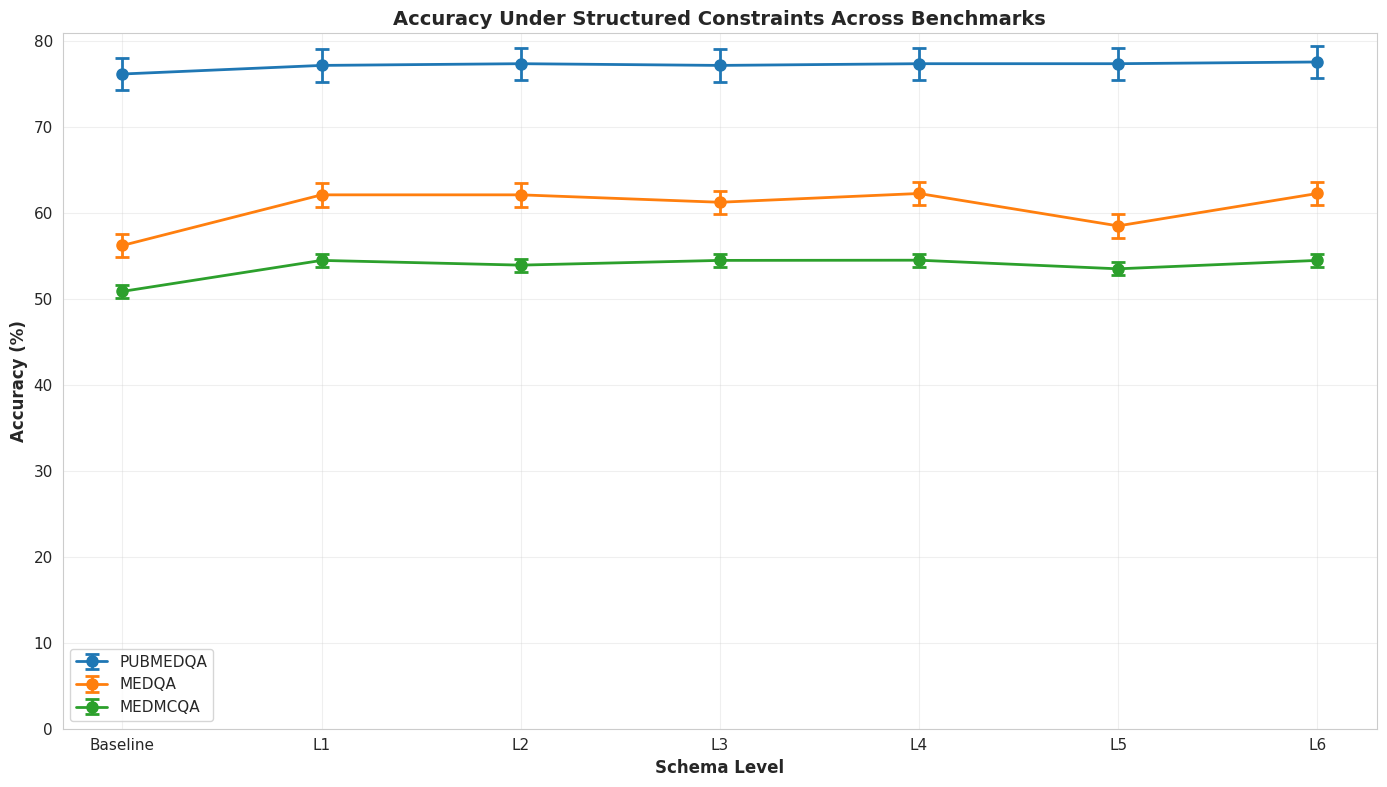

In [7]:
# Create accuracy comparison visualizations

# 1. Multi-benchmark accuracy comparison (line plot with error bars)
fig, ax = plt.subplots(figsize=(14, 8))

# Define level order
level_order = ['baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']
level_labels = ['Baseline', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    # Filter to available levels and sort
    bench_data = bench_data[bench_data['level'].isin(level_order)]
    bench_data['level_num'] = bench_data['level'].map({l: i for i, l in enumerate(level_order) if l in bench_data['level'].values})
    bench_data = bench_data.sort_values('level_num')
    
    x_pos = bench_data['level_num'].values
    y_vals = bench_data['accuracy'].values * 100
    y_err = bench_data['accuracy_stderr'].values * 100
    
    ax.errorbar(x_pos, y_vals, yerr=y_err, marker='o', linewidth=2, 
                markersize=8, label=benchmark.upper(), capsize=5, capthick=2)

ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Under Structured Constraints Across Benchmarks', fontsize=14, fontweight='bold')
ax.set_xticks(range(len([l for l in level_order if l in accuracy_df['level'].values])))
ax.set_xticklabels([l for l in level_labels if l.replace('Baseline', 'baseline') in accuracy_df['level'].values])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


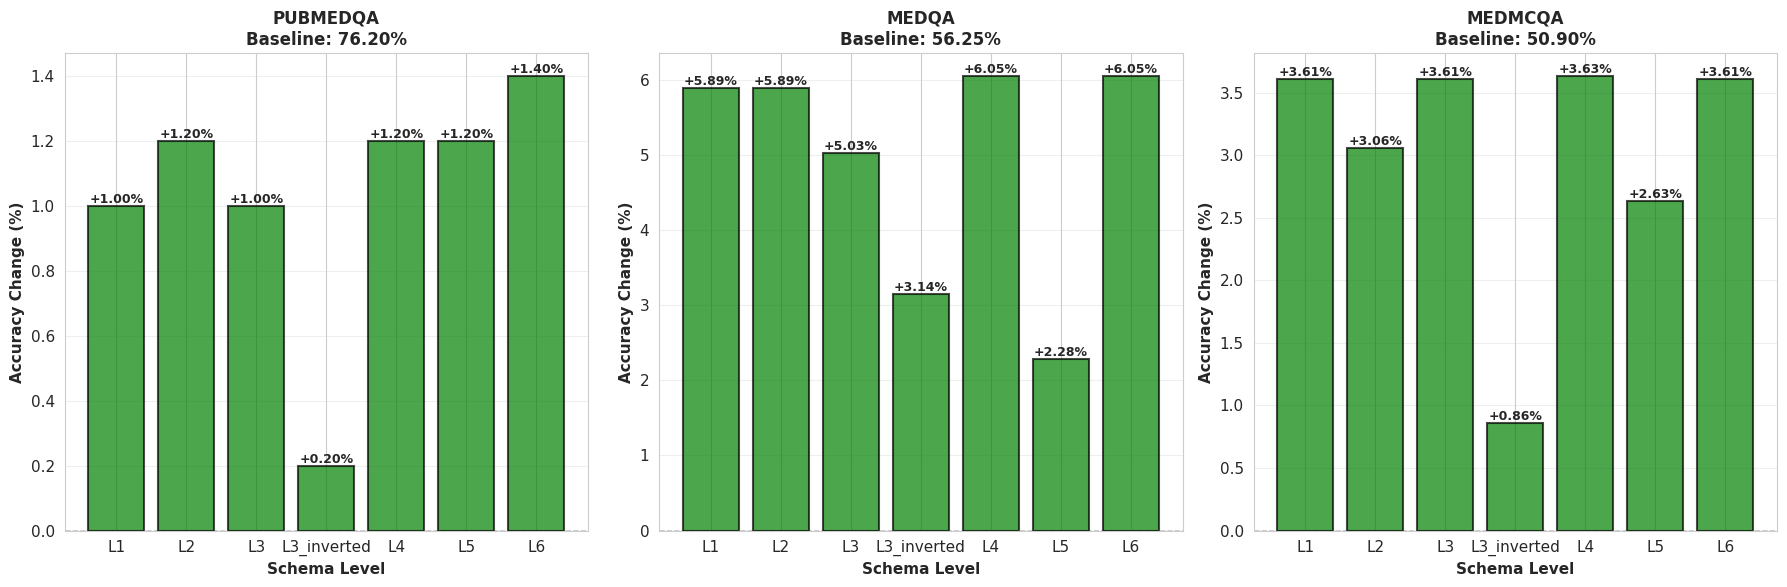

In [8]:
# 2. Accuracy change from baseline (bar chart)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
benchmarks = ['pubmedqa', 'medqa', 'medmcqa']

for idx, benchmark in enumerate(benchmarks):
    ax = axes[idx]
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    
    # Get baseline accuracy
    baseline_data = bench_data[bench_data['level'] == 'baseline']
    if len(baseline_data) > 0:
        baseline_acc = baseline_data['accuracy'].values[0] * 100
    else:
        # For pubmedqa, use L1 as reference
        baseline_acc = bench_data[bench_data['level'] == 'L1']['accuracy'].values[0] * 100 if len(bench_data[bench_data['level'] == 'L1']) > 0 else 0
    
    # Calculate change from baseline
    bench_data = bench_data[bench_data['level'] != 'baseline']
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    changes = (bench_data['accuracy'].values * 100) - baseline_acc
    
    colors = ['green' if c > 0 else 'red' for c in changes]
    bars = ax.bar(levels, changes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy Change (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nBaseline: {baseline_acc:.2f}%', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, change in zip(bars, changes):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{change:+.2f}%', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_change_from_baseline.png', dpi=300, bbox_inches='tight')
plt.show()


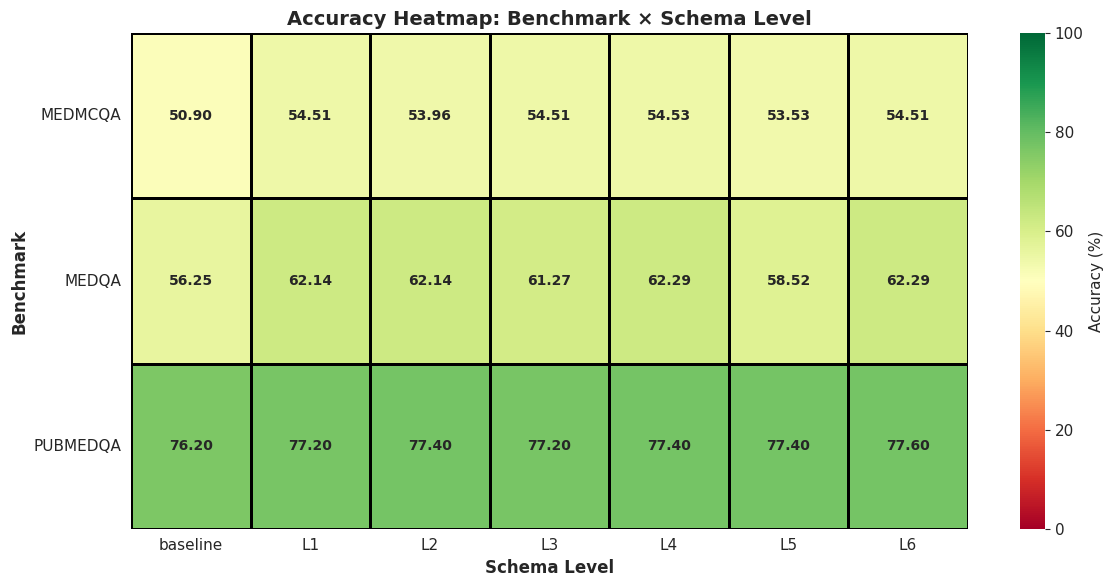

In [9]:
# 3. Heatmap showing accuracy by benchmark and level
pivot_data = accuracy_df.pivot(index='benchmark', columns='level', values='accuracy') * 100

# Reorder columns
level_order_available = [l for l in level_order if l in pivot_data.columns]
pivot_data = pivot_data[level_order_available]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Accuracy (%)'}, linewidths=1, linecolor='black',
            ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Heatmap: Benchmark × Schema Level', fontsize=14, fontweight='bold')
ax.set_yticklabels([b.upper() for b in pivot_data.index], rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
# 4. Statistical significance tests between levels
print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS: Accuracy Differences Between Levels")
print("="*80)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    print(f"\n{benchmark.upper()}:")
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    levels = sorted(bench_data['level'].unique())
    
    # Get sample-level accuracy data for statistical tests
    bench_parsed = {}
    for level in levels:
        parsed = all_parsed[benchmark][level]
        bench_parsed[level] = [p['exact_match'] for p in parsed]
    
    # Compare each level with baseline (or L1 for pubmedqa)
    reference = 'baseline' if 'baseline' in levels else 'L1'
    if reference not in bench_parsed:
        continue
    
    ref_acc = np.array(bench_parsed[reference])
    
    for level in levels:
        if level == reference:
            continue
        level_acc = np.array(bench_parsed[level])
        
        # Perform t-test
        t_stat, p_value = stats.ttest_rel(ref_acc, level_acc) if len(ref_acc) == len(level_acc) else stats.ttest_ind(ref_acc, level_acc)
        
        mean_diff = np.mean(level_acc) - np.mean(ref_acc)
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        
        print(f"  {reference} vs {level}: Δ = {mean_diff*100:+.2f}%, p = {p_value:.4f} {significance}")

print("="*80)


STATISTICAL SIGNIFICANCE TESTS: Accuracy Differences Between Levels

PUBMEDQA:
  baseline vs L1: Δ = +1.00%, p = 0.4463 
  baseline vs L2: Δ = +1.20%, p = 0.3769 
  baseline vs L3: Δ = +1.00%, p = 0.4463 
  baseline vs L3_inverted: Δ = +0.20%, p = 0.8966 
  baseline vs L4: Δ = +1.20%, p = 0.3769 
  baseline vs L5: Δ = +1.20%, p = 0.3662 
  baseline vs L6: Δ = +1.40%, p = 0.2972 

MEDQA:
  baseline vs L1: Δ = +5.89%, p = 0.0000 ***
  baseline vs L2: Δ = +5.89%, p = 0.0000 ***
  baseline vs L3: Δ = +5.03%, p = 0.0000 ***
  baseline vs L3_inverted: Δ = +3.14%, p = 0.0281 *
  baseline vs L4: Δ = +6.05%, p = 0.0000 ***
  baseline vs L5: Δ = +2.28%, p = 0.0596 
  baseline vs L6: Δ = +6.05%, p = 0.0000 ***

MEDMCQA:
  baseline vs L1: Δ = +3.61%, p = 0.0000 ***
  baseline vs L2: Δ = +3.06%, p = 0.0000 ***
  baseline vs L3: Δ = +3.61%, p = 0.0000 ***
  baseline vs L3_inverted: Δ = +0.86%, p = 0.2860 
  baseline vs L4: Δ = +3.63%, p = 0.0000 ***
  baseline vs L5: Δ = +2.63%, p = 0.0002 ***
  bas

## 4.2 Output Validity and Schema Compliance

This section analyzes how well models follow structured schemas, including:
1. **JSON Validity Rates (Parseable Answer Rates)**: For baseline, this measures the rate of parseable answers extracted from text. For schema levels, this measures the rate of valid JSON that can be parsed.
2. **Conditional Schema Compliance**: Among samples with valid JSON, the percentage that are schema-compliant.
3. **Compliance Breakdown**: Stacked visualization showing Valid JSON + Compliant, Valid JSON + Non-Compliant, and Invalid JSON categories across all levels.


In [11]:
# Compute compliance metrics
compliance_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        
        n_total = len(parsed)
        n_json_valid = sum(1 for p in parsed if p['json_valid'])
        n_schema_compliant = sum(1 for p in parsed if p['schema_compliant'])
        n_has_answer = sum(1 for p in parsed if p['has_answer'])
        n_invalid_answer = sum(1 for p in parsed if p['answer'] == '[invalid]')
        n_has_confidence = sum(1 for p in parsed if p['has_confidence'])
        n_has_reasoning = sum(1 for p in parsed if p['has_reasoning'])
        n_has_justification = sum(1 for p in parsed if p['has_justification'])
        n_has_eliminated = sum(1 for p in parsed if p['has_eliminated'])
        n_has_key_evidence = sum(1 for p in parsed if p['has_key_evidence'])
        n_has_key_concepts = sum(1 for p in parsed if p['has_key_concepts'])
        
        # Compute parseable answer rate
        # For baseline: has_answer=True (answers extracted from text)
        # For schema levels: json_valid=True (valid JSON that can be parsed)
        if level == 'baseline':
            n_parseable = n_has_answer
        else:
            n_parseable = n_json_valid
        
        # Compute conditional schema compliance rate (within valid JSON)
        # Only for schema levels, not baseline
        if level != 'baseline' and n_json_valid > 0:
            schema_compliant_given_valid_json = n_schema_compliant / n_json_valid
        else:
            schema_compliant_given_valid_json = np.nan
        
        # Compute categories for stacked bar plot
        if level == 'baseline':
            # For baseline: use has_answer instead of json_valid
            # Valid + Compliant = has_answer=True (since schema_compliant = has_answer for baseline)
            # Invalid = has_answer=False
            n_valid_json_compliant = sum(1 for p in parsed if p['has_answer'] and p['schema_compliant'])
            n_valid_json_non_compliant = sum(1 for p in parsed if p['has_answer'] and not p['schema_compliant'])
            n_invalid_json = sum(1 for p in parsed if not p['has_answer'])
        else:
            # For schema levels: use json_valid
            n_valid_json_compliant = sum(1 for p in parsed if p['json_valid'] and p['schema_compliant'])
            n_valid_json_non_compliant = sum(1 for p in parsed if p['json_valid'] and not p['schema_compliant'])
            n_invalid_json = n_total - n_json_valid
        
        compliance_data.append({
            'benchmark': benchmark,
            'level': level,
            'n_total': n_total,
            'json_valid_rate': n_json_valid / n_total if n_total > 0 else 0,
            'schema_compliant_rate': n_schema_compliant / n_total if n_total > 0 else 0,
            'parseable_answer_rate': n_parseable / n_total if n_total > 0 else 0,
            'schema_compliant_rate_given_valid_json': schema_compliant_given_valid_json,
            'has_answer_rate': n_has_answer / n_total if n_total > 0 else 0,
            'invalid_answer_rate': n_invalid_answer / n_total if n_total > 0 else 0,
            'has_confidence_rate': n_has_confidence / n_total if n_total > 0 else 0,
            'has_reasoning_rate': n_has_reasoning / n_total if n_total > 0 else 0,
            'has_justification_rate': n_has_justification / n_total if n_total > 0 else 0,
            'has_eliminated_rate': n_has_eliminated / n_total if n_total > 0 else 0,
            'has_key_evidence_rate': n_has_key_evidence / n_total if n_total > 0 else 0,
            'has_key_concepts_rate': n_has_key_concepts / n_total if n_total > 0 else 0,
            # For stacked bar plot
            'n_valid_json_compliant': n_valid_json_compliant,
            'n_valid_json_non_compliant': n_valid_json_non_compliant,
            'n_invalid_json': n_invalid_json,
            'rate_valid_json_compliant': n_valid_json_compliant / n_total if n_total > 0 else 0,
            'rate_valid_json_non_compliant': n_valid_json_non_compliant / n_total if n_total > 0 else 0,
            'rate_invalid_json': n_invalid_json / n_total if n_total > 0 else 0,
        })

compliance_df = pd.DataFrame(compliance_data)
print("Compliance metrics computed")
print(compliance_df.groupby('benchmark')[['json_valid_rate', 'schema_compliant_rate']].mean())


Compliance metrics computed
           json_valid_rate  schema_compliant_rate
benchmark                                        
medmcqa           0.775341               0.884921
medqa             0.763060               0.855165
pubmedqa          0.834250               0.958500


In [12]:
# Display JSON validity rates (parseable answer rates) and conditional schema compliance
print("="*100)
print("JSON VALIDITY RATES (PARSEABLE ANSWER RATES) AND CONDITIONAL SCHEMA COMPLIANCE")
print("="*100)
print("\nFor baseline: Parseable Answer Rate = has_answer rate (answers extracted from text)")
print("For schema levels: Parseable Answer Rate = json_valid rate (valid JSON that can be parsed)")
print("Conditional Schema Compliance = percentage of schema-compliant samples among those with valid JSON\n")

# Create summary table
summary_data = []
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        parseable_rate = row['parseable_answer_rate'] * 100
        json_valid_rate = row['json_valid_rate'] * 100
        schema_compliant_rate = row['schema_compliant_rate'] * 100
        
        # Conditional compliance (only for schema levels)
        if level != 'baseline' and not pd.isna(row['schema_compliant_rate_given_valid_json']):
            conditional_compliance = row['schema_compliant_rate_given_valid_json'] * 100
            conditional_str = f"{conditional_compliance:.2f}%"
        else:
            conditional_str = "N/A"
        
        summary_data.append({
            'Benchmark': benchmark.upper(),
            'Level': level,
            'Parseable Answer Rate (%)': f"{parseable_rate:.2f}",
            'JSON Valid Rate (%)': f"{json_valid_rate:.2f}",
            'Schema Compliant Rate (%)': f"{schema_compliant_rate:.2f}",
            'Schema Compliant (within Valid JSON) (%)': conditional_str
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*100)


JSON VALIDITY RATES (PARSEABLE ANSWER RATES) AND CONDITIONAL SCHEMA COMPLIANCE

For baseline: Parseable Answer Rate = has_answer rate (answers extracted from text)
For schema levels: Parseable Answer Rate = json_valid rate (valid JSON that can be parsed)
Conditional Schema Compliance = percentage of schema-compliant samples among those with valid JSON

Benchmark       Level Parseable Answer Rate (%) JSON Valid Rate (%) Schema Compliant Rate (%) Schema Compliant (within Valid JSON) (%)
 PUBMEDQA          L1                    100.00              100.00                    100.00                                  100.00%
 PUBMEDQA          L2                    100.00              100.00                    100.00                                  100.00%
 PUBMEDQA          L3                     97.60               97.60                     97.60                                  100.00%
 PUBMEDQA L3_inverted                     95.80               95.80                     95.80            

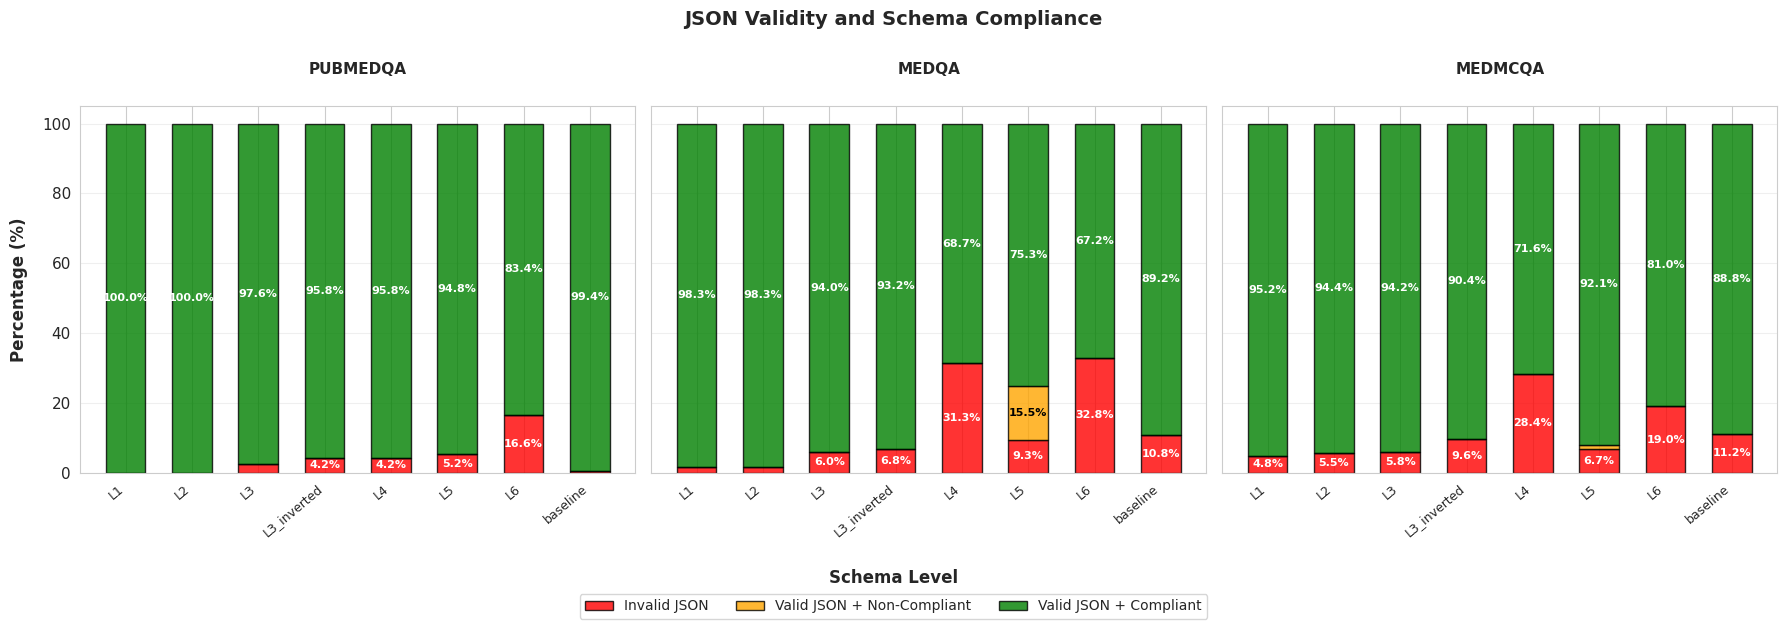

In [22]:
# 1. Stacked bar chart: Valid JSON + Compliant, Valid JSON + Non-Compliant, Invalid JSON
# Create subplots with shared axes - increase height to accommodate all elements
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# Single title for all subplots - vertically centered above subplots
fig.suptitle('JSON Validity and Schema Compliance', fontsize=14, fontweight='bold', y=0.9)

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    # Get rates as percentages
    rate_invalid_json = bench_data['rate_invalid_json'].values * 100
    rate_valid_json_non_compliant = bench_data['rate_valid_json_non_compliant'].values * 100
    rate_valid_json_compliant = bench_data['rate_valid_json_compliant'].values * 100
    
    x = np.arange(len(levels))
    width = 0.6
    
    # Stack bars from bottom to top: Invalid JSON (bottom), Valid JSON + Non-Compliant (middle), Valid JSON + Compliant (top)
    bars1 = ax.bar(x, rate_invalid_json, width, label='Invalid JSON', alpha=0.8, color='red', edgecolor='black', linewidth=1)
    bars2 = ax.bar(x, rate_valid_json_non_compliant, width, bottom=rate_invalid_json, 
                   label='Valid JSON + Non-Compliant', alpha=0.8, color='orange', edgecolor='black', linewidth=1)
    bars3 = ax.bar(x, rate_valid_json_compliant, width, 
                   bottom=rate_invalid_json + rate_valid_json_non_compliant,
                   label='Valid JSON + Compliant', alpha=0.8, color='green', edgecolor='black', linewidth=1)
    
    # Only show y-axis label on left subplot (first one)
    if idx == 0:
        ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold', labelpad=10)
    
    # Add benchmark label as subtitle - position in the top margin, well above plot area
    ax.text(0.5, 1.08, benchmark.upper(), transform=ax.transAxes, 
            fontsize=11, fontweight='bold', ha='center', va='bottom')
    
    ax.set_xticks(x)
    # Improve x-axis label readability - reduce rotation slightly and adjust alignment
    ax.set_xticklabels(levels, rotation=40, ha='right', fontsize=9)
    
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 105)
    
    # Add value labels on segments (only if segment is large enough to be visible)
    for i, (bar1, bar2, bar3) in enumerate(zip(bars1, bars2, bars3)):
        # Invalid JSON label
        h1 = bar1.get_height()
        if h1 > 3:  # Only label if segment is > 3%
            ax.text(bar1.get_x() + bar1.get_width()/2., h1/2,
                    f'{h1:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Valid JSON + Non-Compliant label
        h2 = bar2.get_height()
        bottom2 = bar2.get_y()
        if h2 > 3:  # Only label if segment is > 3%
            ax.text(bar2.get_x() + bar2.get_width()/2., bottom2 + h2/2,
                    f'{h2:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='black')
        
        # Valid JSON + Compliant label
        h3 = bar3.get_height()
        bottom3 = bar3.get_y()
        if h3 > 3:  # Only label if segment is > 3%
            ax.text(bar3.get_x() + bar3.get_width()/2., bottom3 + h3/2,
                    f'{h3:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

# Create shared legend at the bottom center of the figure (below x-axis label)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=True, 
           bbox_to_anchor=(0.5, 0.02))

# Add centered x-axis label above legend
fig.text(0.5, 0.075, 'Schema Level', fontsize=12, fontweight='bold', ha='center', va='bottom')

# Adjust layout to accommodate shared title, benchmark labels, and legend
plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.savefig(PLOTS_DIR / 'json_validity_compliance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


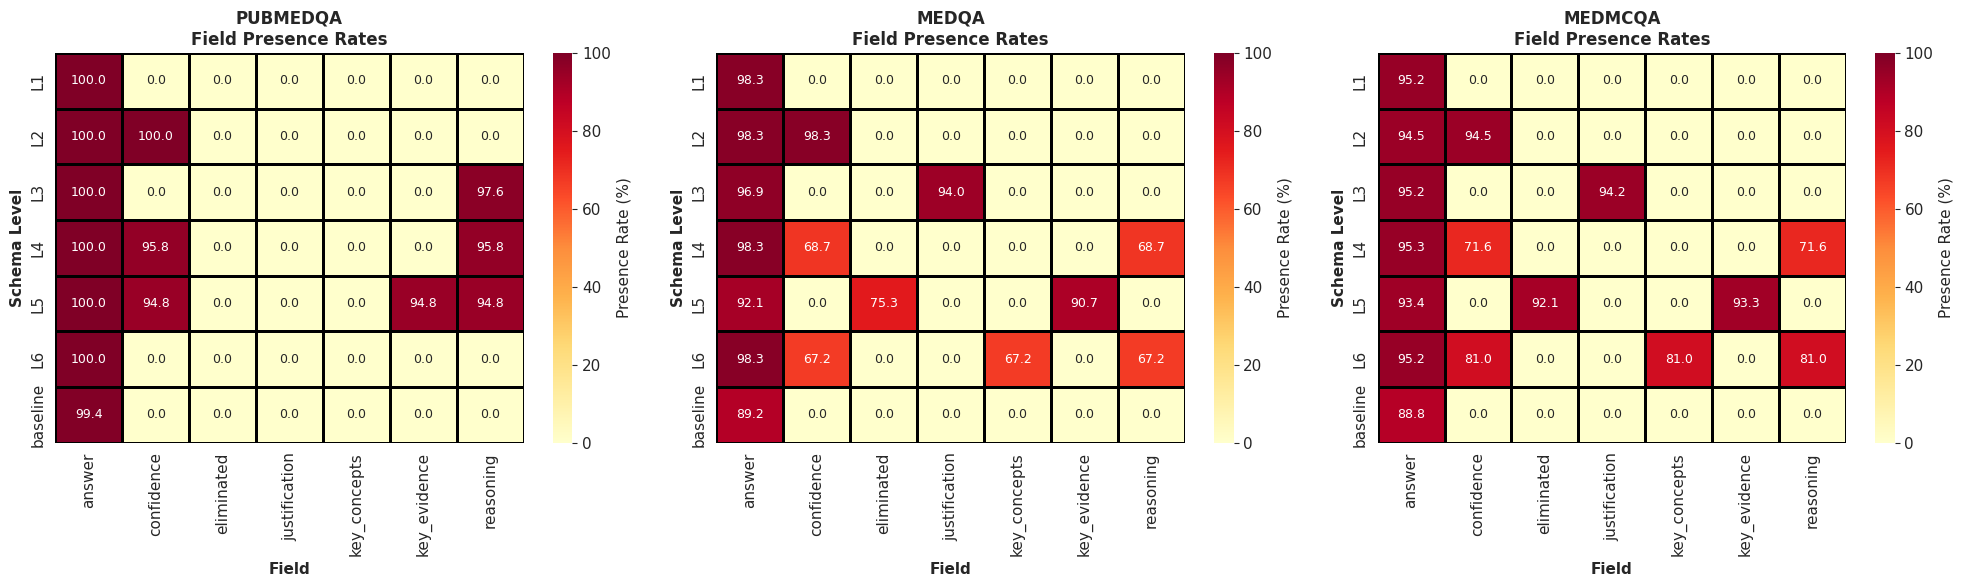

In [14]:
# 2. Field presence heatmap
field_columns = ['has_answer_rate', 'has_confidence_rate', 'has_reasoning_rate', 
                 'has_justification_rate', 'has_eliminated_rate', 'has_key_evidence_rate', 
                 'has_key_concepts_rate']

# Create a combined dataframe for heatmap
heatmap_data = []
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in compliance_df[compliance_df['benchmark'] == benchmark]['level'].unique():
        row_data = compliance_df[(compliance_df['benchmark'] == benchmark) & 
                                 (compliance_df['level'] == level)].iloc[0]
        for field in field_columns:
            heatmap_data.append({
                'benchmark': benchmark,
                'level': level,
                'field': field.replace('_rate', '').replace('has_', ''),
                'rate': row_data[field] * 100
            })

heatmap_df = pd.DataFrame(heatmap_data)
pivot_heatmap = heatmap_df.pivot_table(index=['benchmark', 'level'], columns='field', values='rate')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_heatmap = pivot_heatmap.loc[benchmark]
    sns.heatmap(bench_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
                cbar_kws={'label': 'Presence Rate (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 9})
    ax.set_xlabel('Field', fontsize=11, fontweight='bold')
    ax.set_ylabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nField Presence Rates', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'field_presence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


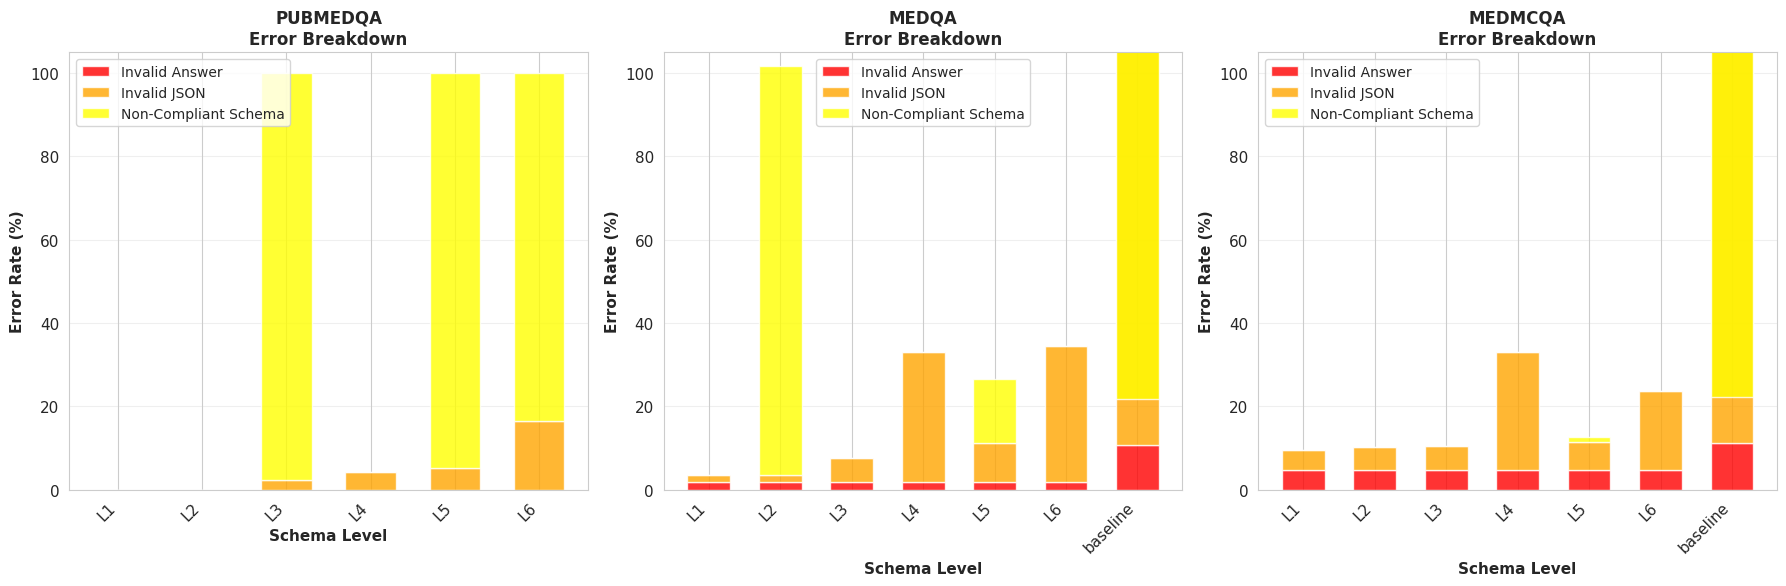

In [28]:
# 3. Compliance breakdown by error type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    invalid_answers = bench_data['invalid_answer_rate'].values * 100
    json_invalid = (1 - bench_data['json_valid_rate'].values) * 100
    non_compliant = (bench_data['json_valid_rate'].values - bench_data['schema_compliant_rate'].values) * 100
    
    x = np.arange(len(levels))
    width = 0.6
    
    bottom1 = invalid_answers
    bottom2 = bottom1 + json_invalid
    
    ax.bar(x, invalid_answers, width, label='Invalid Answer', alpha=0.8, color='red')
    ax.bar(x, json_invalid, width, bottom=bottom1, label='Invalid JSON', alpha=0.8, color='orange')
    ax.bar(x, non_compliant, width, bottom=bottom2, label='Non-Compliant Schema', alpha=0.8, color='yellow')
    
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('Error Rate (%)', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nError Breakdown', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(levels, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'compliance_error_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()


## 4.3 Confidence and Calibration Behavior

This section analyzes model calibration: how well confidence scores correlate with actual accuracy, and whether structured constraints affect calibration.


In [29]:
# Compute Expected Calibration Error (ECE)
def compute_ece(confidences, correct, n_bins=10):
    """Compute Expected Calibration Error."""
    if len(confidences) == 0 or len(correct) == 0:
        return np.nan
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = correct[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

# Extract confidence and correctness data
calibration_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        
        # Filter to samples with confidence
        conf_samples = [p for p in parsed if p['has_confidence'] and p['confidence'] is not None]
        
        if len(conf_samples) == 0:
            continue
        
        confidences = np.array([p['confidence'] for p in conf_samples])
        correct = np.array([p['exact_match'] for p in conf_samples])
        
        ece = compute_ece(confidences, correct)
        mean_confidence = np.mean(confidences)
        mean_accuracy = np.mean(correct)
        correlation = np.corrcoef(confidences, correct)[0, 1] if len(confidences) > 1 else np.nan
        
        calibration_data.append({
            'benchmark': benchmark,
            'level': level,
            'n_with_confidence': len(conf_samples),
            'ece': ece,
            'mean_confidence': mean_confidence,
            'mean_accuracy': mean_accuracy,
            'correlation': correlation,
            'confidences': confidences,
            'correct': correct,
        })

calibration_df = pd.DataFrame([{k: v for k, v in d.items() if k not in ['confidences', 'correct']} 
                                for d in calibration_data])
print("Calibration metrics computed")
print(calibration_df.groupby('benchmark')[['ece', 'correlation']].mean())


Calibration metrics computed
                ece  correlation
benchmark                       
medmcqa    0.303002     0.031356
medqa      0.286796     0.009947
pubmedqa   0.196713     0.088443


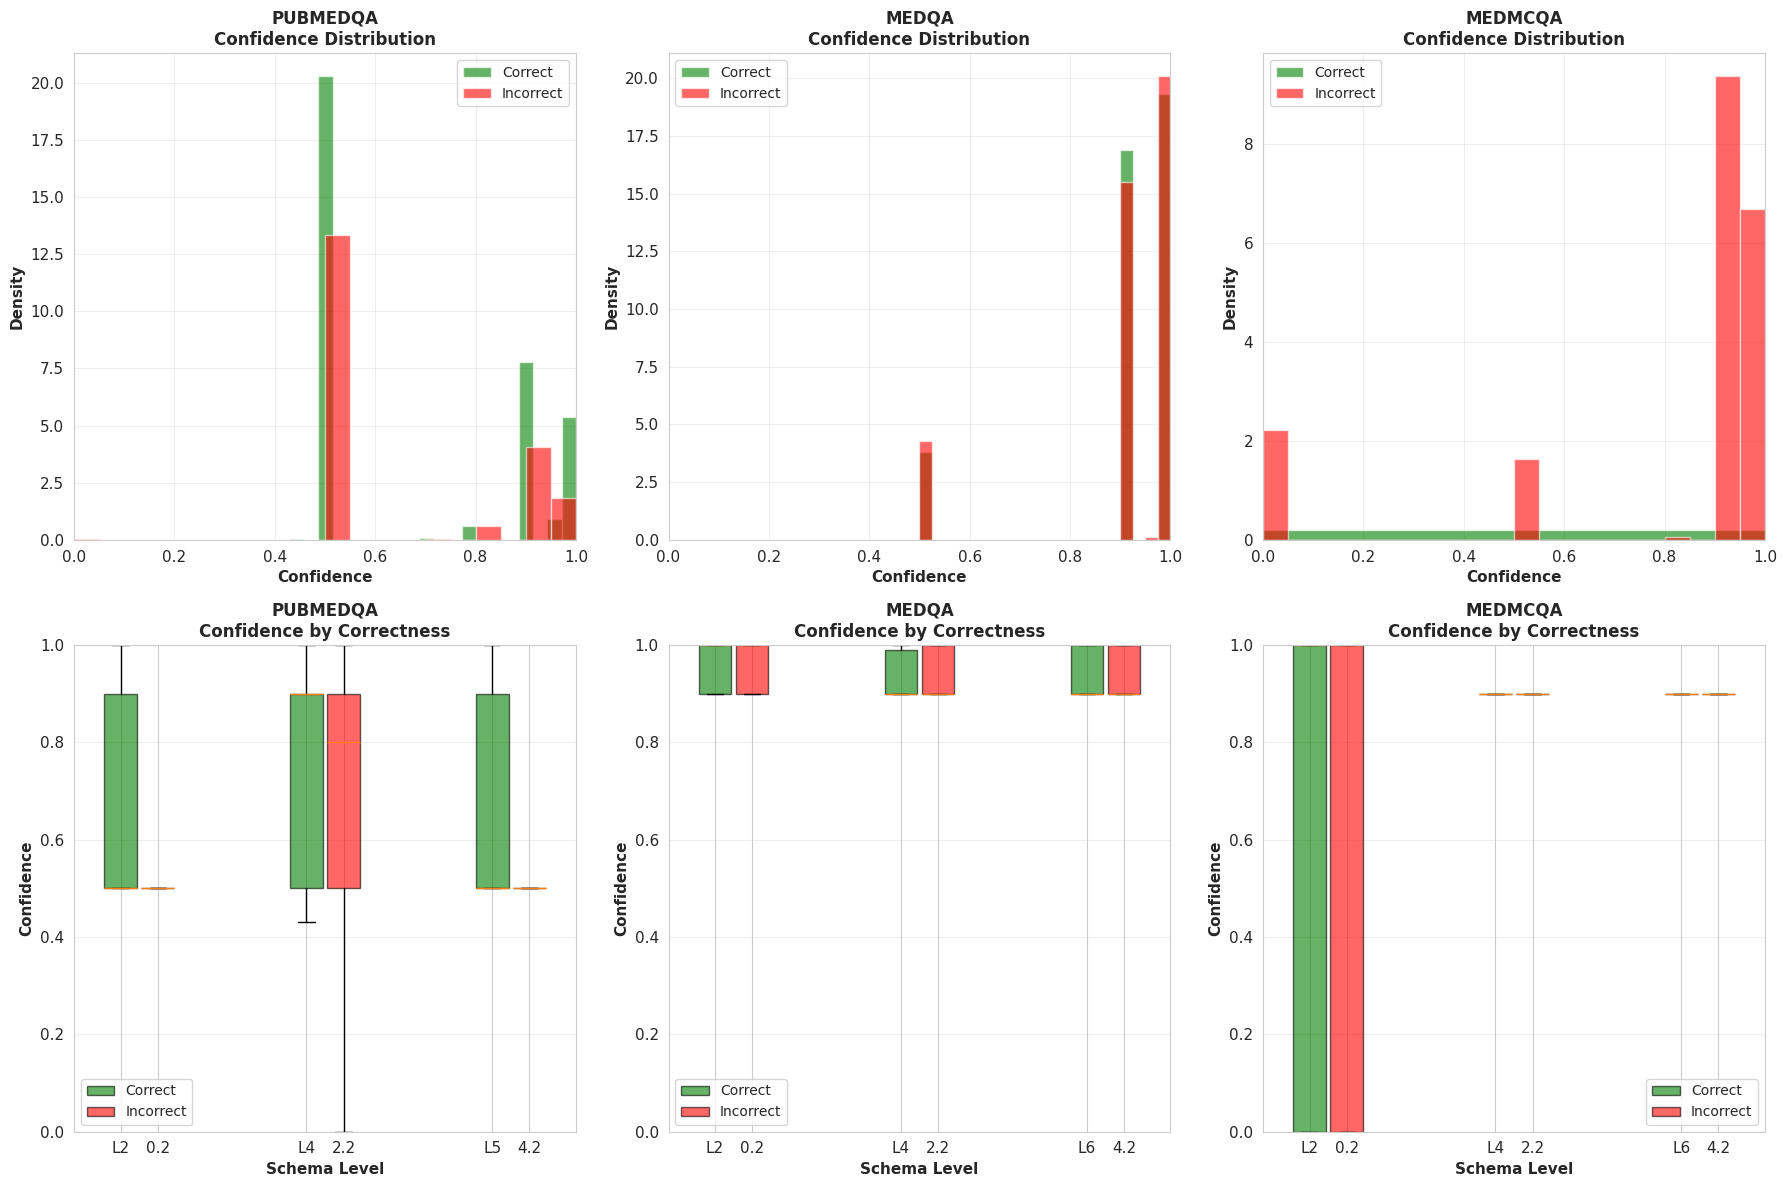

In [30]:
# 1. Confidence distributions (correct vs incorrect answers)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    # Get all confidence data for this benchmark
    all_conf_correct = []
    all_conf_incorrect = []
    
    for calib_item in calibration_data:
        if calib_item['benchmark'] == benchmark:
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            all_conf_correct.extend(confidences[correct == 1])
            all_conf_incorrect.extend(confidences[correct == 0])
    
    if len(all_conf_correct) > 0 or len(all_conf_incorrect) > 0:
        ax = axes[0, idx]
        ax.hist(all_conf_correct, bins=20, alpha=0.6, label='Correct', color='green', density=True)
        ax.hist(all_conf_incorrect, bins=20, alpha=0.6, label='Incorrect', color='red', density=True)
        ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
        ax.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax.set_title(f'{benchmark.upper()}\nConfidence Distribution', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
    
    # Confidence by correctness (box plot)
    ax = axes[1, idx]
    conf_by_level = []
    labels = []
    
    for level in sorted(set([c['level'] for c in calibration_data if c['benchmark'] == benchmark])):
        calib_item = next((c for c in calibration_data if c['benchmark'] == benchmark and c['level'] == level), None)
        if calib_item:
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            conf_by_level.append([confidences[correct == 1], confidences[correct == 0]])
            labels.append(level)
    
    if conf_by_level:
        correct_confs = [c[0] for c in conf_by_level if len(c[0]) > 0]
        incorrect_confs = [c[1] for c in conf_by_level if len(c[1]) > 0]
        
        positions_correct = np.arange(len(correct_confs)) * 2 - 0.2
        positions_incorrect = np.arange(len(incorrect_confs)) * 2 + 0.2
        
        bp1 = ax.boxplot(correct_confs, positions=positions_correct, widths=0.35, 
                         patch_artist=True, labels=labels, showfliers=False)
        bp2 = ax.boxplot(incorrect_confs, positions=positions_incorrect, widths=0.35,
                         patch_artist=True, showfliers=False)
        
        for patch in bp1['boxes']:
            patch.set_facecolor('green')
            patch.set_alpha(0.6)
        for patch in bp2['boxes']:
            patch.set_facecolor('red')
            patch.set_alpha(0.6)
        
        ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
        ax.set_ylabel('Confidence', fontsize=11, fontweight='bold')
        ax.set_title(f'{benchmark.upper()}\nConfidence by Correctness', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 1)
        ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Correct', 'Incorrect'], fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confidence_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


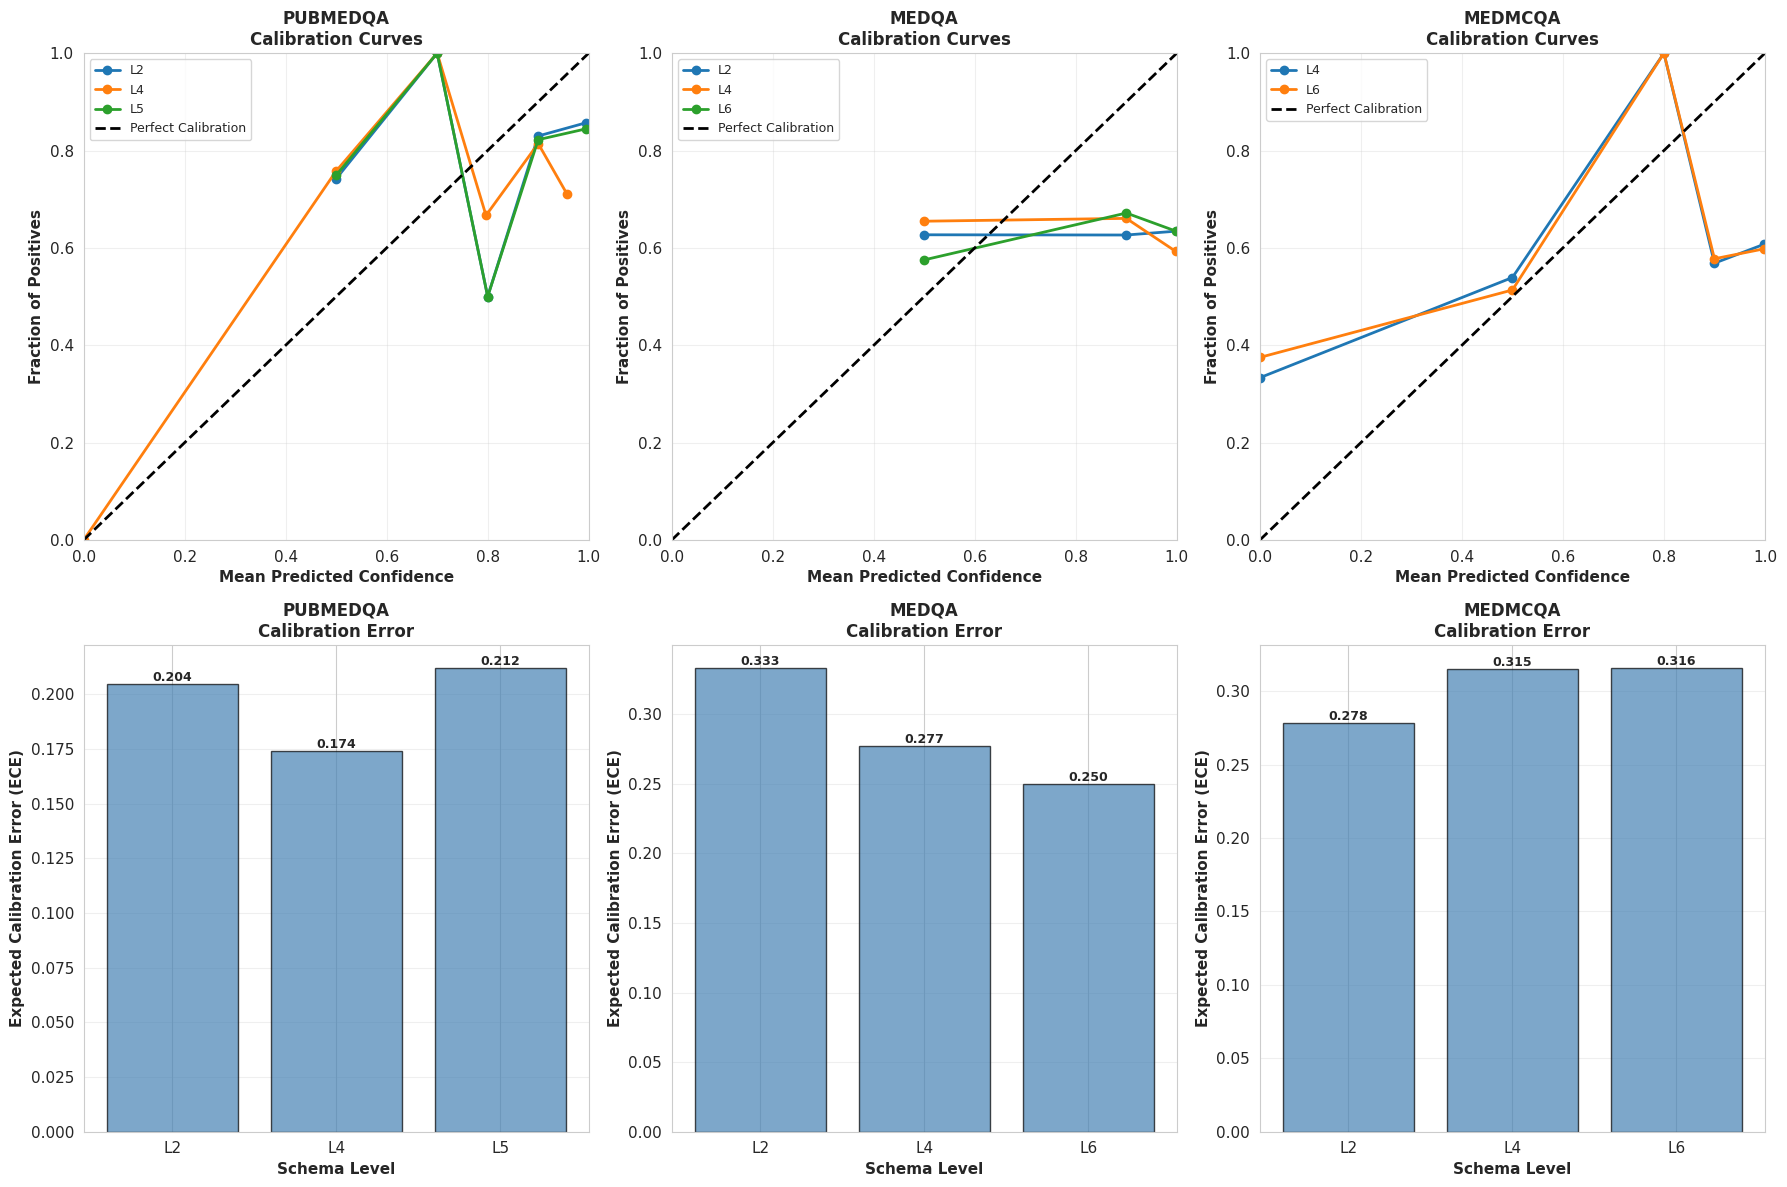

In [31]:
# 2. Calibration curves for each benchmark/level
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax1 = axes[0, idx]
    ax2 = axes[1, idx]
    
    for calib_item in calibration_data:
        if calib_item['benchmark'] == benchmark:
            level = calib_item['level']
            confidences = calib_item['confidences']
            correct = calib_item['correct']
            
            if len(confidences) > 10:  # Need enough samples
                try:
                    fraction_of_positives, mean_predicted_value = calibration_curve(
                        correct, confidences, n_bins=10, strategy='uniform'
                    )
                    ax1.plot(mean_predicted_value, fraction_of_positives, marker='o', 
                            label=level, linewidth=2, markersize=6)
                except:
                    pass
    
    # Perfect calibration line
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.set_xlabel('Mean Predicted Confidence', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
    ax1.set_title(f'{benchmark.upper()}\nCalibration Curves', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # ECE comparison
    bench_calib = calibration_df[calibration_df['benchmark'] == benchmark].copy()
    bench_calib = bench_calib.sort_values('level')
    
    if len(bench_calib) > 0:
        ax2.bar(bench_calib['level'], bench_calib['ece'], alpha=0.7, color='steelblue', edgecolor='black')
        ax2.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Expected Calibration Error (ECE)', fontsize=11, fontweight='bold')
        ax2.set_title(f'{benchmark.upper()}\nCalibration Error', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, (level, ece) in enumerate(zip(bench_calib['level'], bench_calib['ece'])):
            ax2.text(i, ece, f'{ece:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()


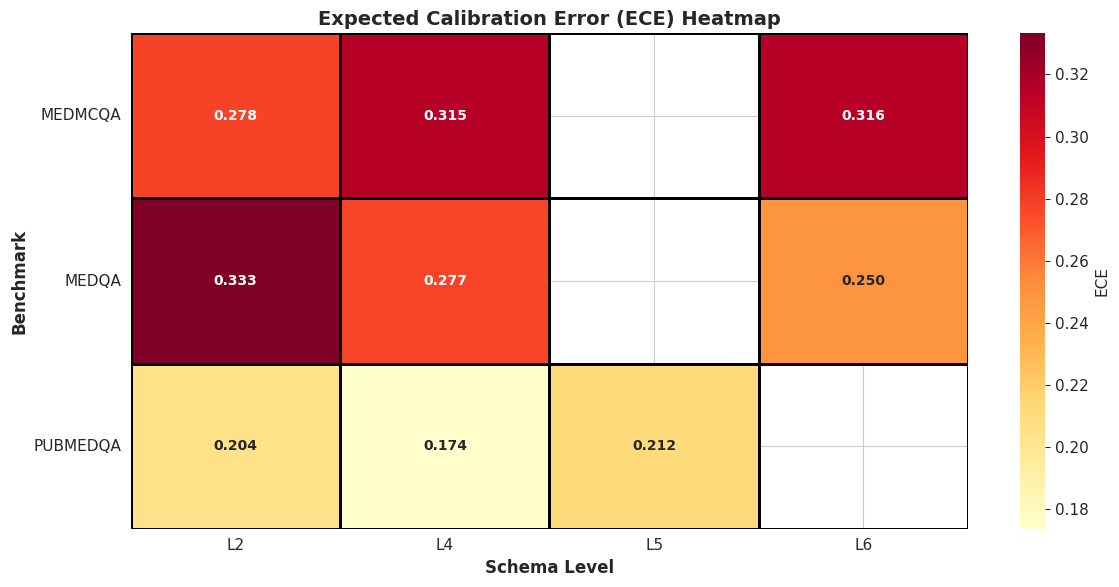

In [32]:
# 3. ECE comparison across levels (heatmap)
ece_pivot = calibration_df.pivot(index='benchmark', columns='level', values='ece')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ece_pivot, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'ECE'}, linewidths=1, linecolor='black',
            ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_title('Expected Calibration Error (ECE) Heatmap', fontsize=14, fontweight='bold')
ax.set_yticklabels([b.upper() for b in ece_pivot.index], rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ece_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## 4.4 Decision Distribution Shifts

This section analyzes whether structured constraints change answer patterns, including distribution shifts and answer transition patterns.


In [33]:
# Compute answer distributions and shift metrics
from scipy.stats import entropy

def kl_divergence(p, q):
    """Compute KL divergence between two distributions."""
    p = np.array(p)
    q = np.array(q)
    # Avoid division by zero
    p = p + 1e-10
    q = q + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    return np.sum(p * np.log(p / q))

distribution_data = []

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    # Determine valid answers
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
    else:
        valid_answers = ['A', 'B', 'C', 'D']
    
    # Get reference distribution (baseline or L1)
    reference_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    if reference_level not in all_parsed[benchmark]:
        continue
    
    ref_parsed = all_parsed[benchmark][reference_level]
    ref_answers = [p['answer'] for p in ref_parsed if p['answer'] != '[invalid]']
    ref_counts = Counter(ref_answers)
    ref_dist = np.array([ref_counts.get(a, 0) for a in valid_answers])
    ref_dist = ref_dist / ref_dist.sum() if ref_dist.sum() > 0 else ref_dist
    
    for level in all_parsed[benchmark].keys():
        parsed = all_parsed[benchmark][level]
        answers = [p['answer'] for p in parsed if p['answer'] != '[invalid]']
        counts = Counter(answers)
        dist = np.array([counts.get(a, 0) for a in valid_answers])
        dist = dist / dist.sum() if dist.sum() > 0 else dist
        
        # Compute KL divergence from reference
        kl_div = kl_divergence(dist, ref_dist) if dist.sum() > 0 and ref_dist.sum() > 0 else np.nan
        
        # Compute chi-square test
        if dist.sum() > 0 and ref_dist.sum() > 0:
            observed = dist * len(answers) if len(answers) > 0 else dist
            expected = ref_dist * len(answers) if len(answers) > 0 else ref_dist
            # Avoid zero expected values
            observed = observed + 1e-10
            expected = expected + 1e-10
            chi2_stat = np.sum((observed - expected)**2 / expected)
        else:
            chi2_stat = np.nan
        
        distribution_data.append({
            'benchmark': benchmark,
            'level': level,
            'distribution': dict(zip(valid_answers, dist)),
            'counts': dict(zip(valid_answers, [counts.get(a, 0) for a in valid_answers])),
            'kl_divergence': kl_div,
            'chi2_statistic': chi2_stat,
            'valid_answers': valid_answers,
        })

distribution_df = pd.DataFrame([{k: v for k, v in d.items() if k not in ['distribution', 'counts', 'valid_answers']} 
                                for d in distribution_data])
print("Distribution metrics computed")


Distribution metrics computed


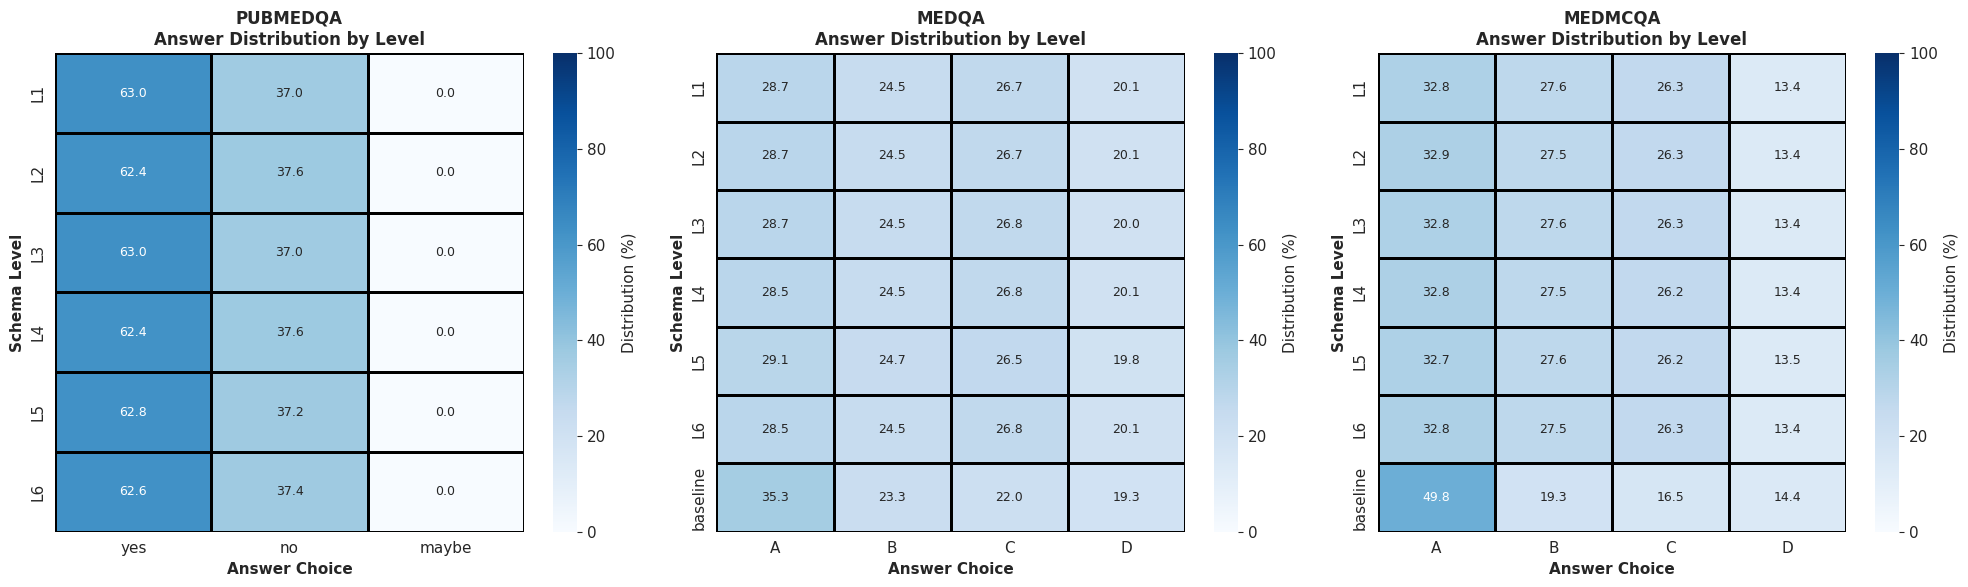

In [34]:
# 1. Answer distribution heatmaps (level × answer choice)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_dist = [d for d in distribution_data if d['benchmark'] == benchmark]
    
    if not bench_dist:
        continue
    
    valid_answers = bench_dist[0]['valid_answers']
    levels = sorted(set([d['level'] for d in bench_dist]))
    
    # Create matrix
    dist_matrix = []
    for level in levels:
        dist_item = next((d for d in bench_dist if d['level'] == level), None)
        if dist_item:
            dist = [dist_item['distribution'].get(a, 0) for a in valid_answers]
            dist_matrix.append(dist)
        else:
            dist_matrix.append([0] * len(valid_answers))
    
    dist_matrix = np.array(dist_matrix) * 100  # Convert to percentage
    
    sns.heatmap(dist_matrix, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100,
                xticklabels=valid_answers, yticklabels=levels,
                cbar_kws={'label': 'Distribution (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 9})
    ax.set_xlabel('Answer Choice', fontsize=11, fontweight='bold')
    ax.set_ylabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nAnswer Distribution by Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'answer_distribution_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


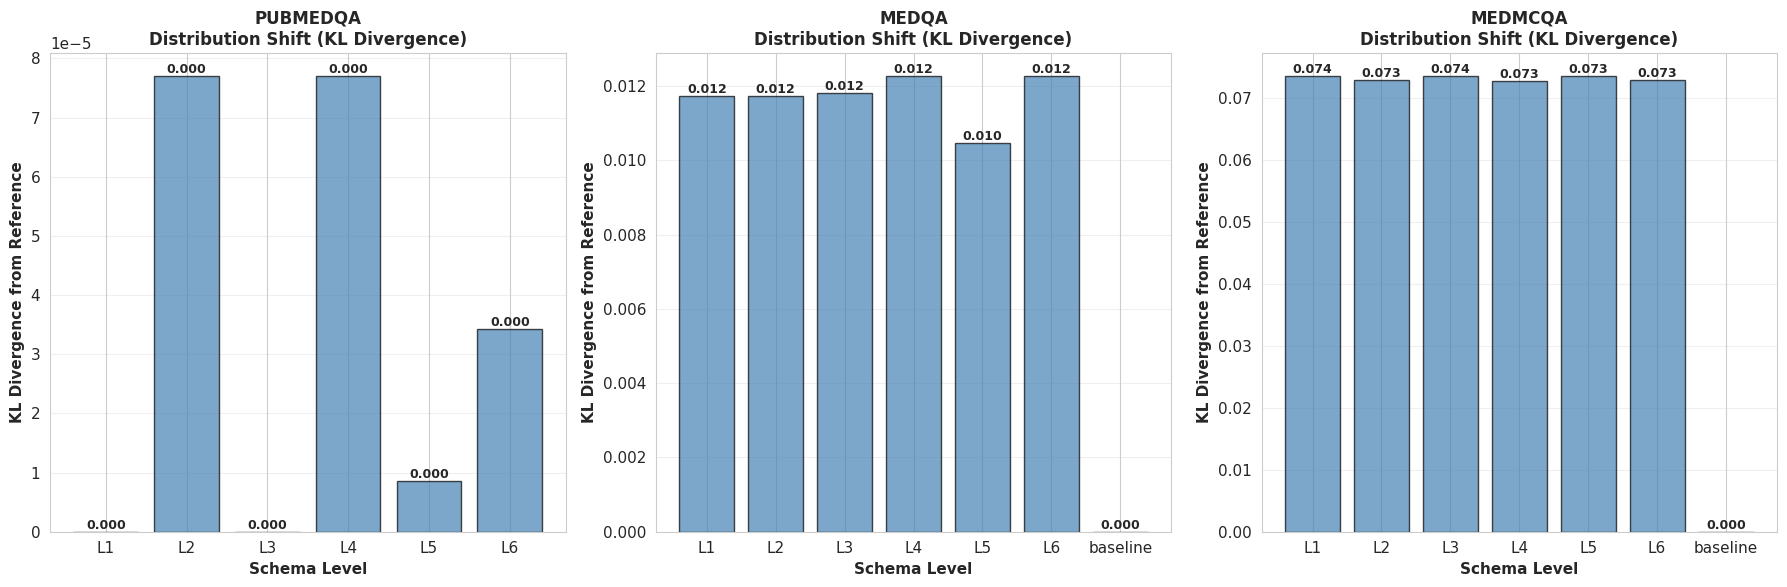

In [35]:
# 2. Distribution shift visualization (KL divergence)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    bench_data = distribution_df[distribution_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    levels = bench_data['level'].values
    kl_divs = bench_data['kl_divergence'].values
    
    bars = ax.bar(levels, kl_divs, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel('Schema Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('KL Divergence from Reference', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nDistribution Shift (KL Divergence)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, kl_div in zip(bars, kl_divs):
        if not np.isnan(kl_div):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{kl_div:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'distribution_shift_kl.png', dpi=300, bbox_inches='tight')
plt.show()


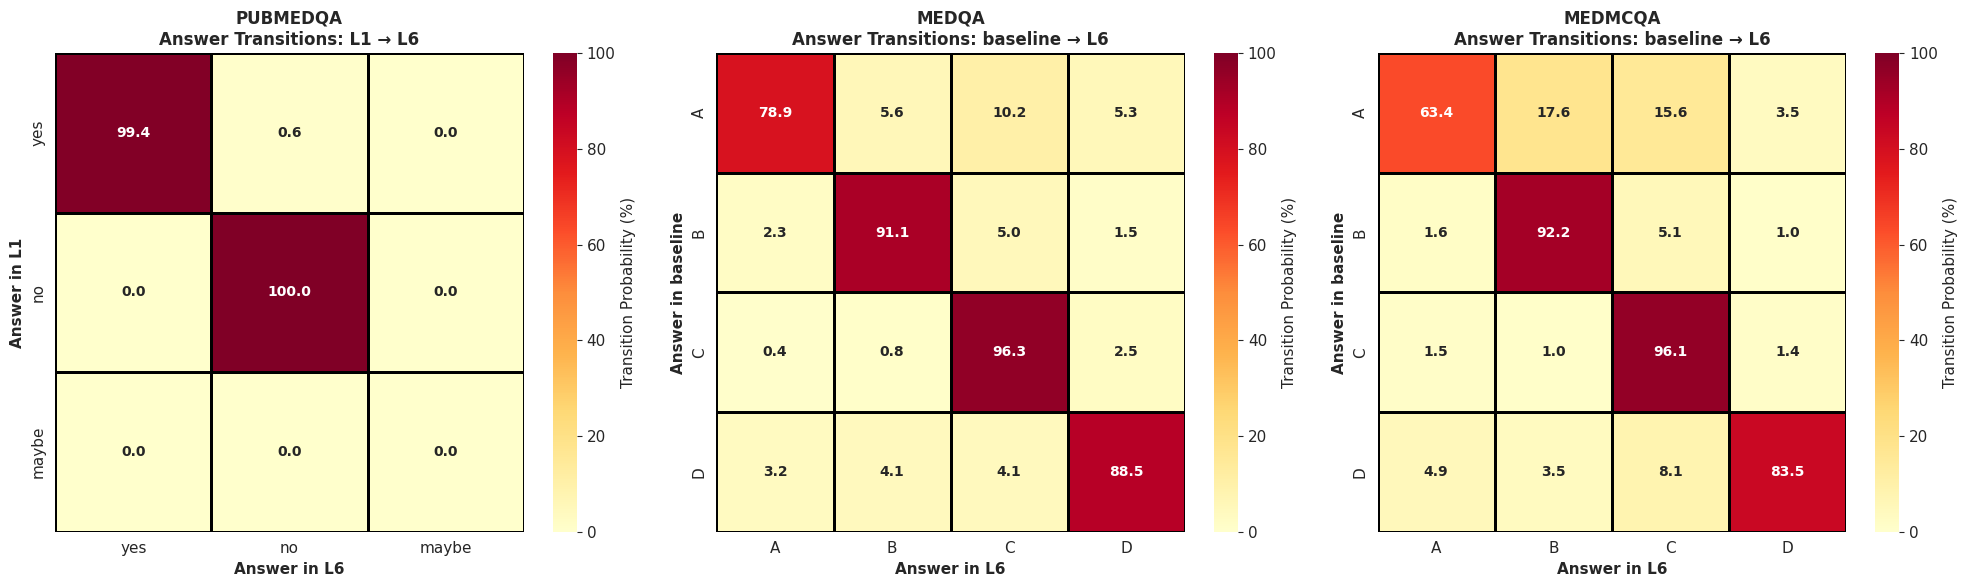

In [36]:
# 3. Answer transition matrices between levels
def create_transition_matrix(benchmark, from_level, to_level):
    """Create transition matrix showing answer changes between levels."""
    from_parsed = all_parsed[benchmark][from_level]
    to_parsed = all_parsed[benchmark][to_level]
    
    # Match by doc_id
    from_dict = {p['doc_id']: p['answer'] for p in from_parsed}
    to_dict = {p['doc_id']: p['answer'] for p in to_parsed}
    
    if benchmark == 'pubmedqa':
        valid_answers = ['yes', 'no', 'maybe']
    else:
        valid_answers = ['A', 'B', 'C', 'D']
    
    # Create transition matrix
    transition = np.zeros((len(valid_answers), len(valid_answers)))
    
    for doc_id in from_dict.keys():
        if doc_id in to_dict:
            from_ans = from_dict[doc_id]
            to_ans = to_dict[doc_id]
            if from_ans in valid_answers and to_ans in valid_answers:
                i = valid_answers.index(from_ans)
                j = valid_answers.index(to_ans)
                transition[i, j] += 1
    
    # Normalize by row
    row_sums = transition.sum(axis=1, keepdims=True)
    transition = transition / (row_sums + 1e-10) * 100
    
    return transition, valid_answers

# Create transition matrices for each benchmark (baseline/L1 to L6)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, benchmark in enumerate(['pubmedqa', 'medqa', 'medmcqa']):
    ax = axes[idx]
    from_level = 'baseline' if 'baseline' in all_parsed[benchmark].keys() else 'L1'
    to_level = 'L6'
    
    if from_level not in all_parsed[benchmark] or to_level not in all_parsed[benchmark]:
        continue
    
    transition, valid_answers = create_transition_matrix(benchmark, from_level, to_level)
    
    sns.heatmap(transition, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
                xticklabels=valid_answers, yticklabels=valid_answers,
                cbar_kws={'label': 'Transition Probability (%)'}, linewidths=1, linecolor='black',
                ax=ax, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_xlabel(f'Answer in {to_level}', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Answer in {from_level}', fontsize=11, fontweight='bold')
    ax.set_title(f'{benchmark.upper()}\nAnswer Transitions: {from_level} → {to_level}', 
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'answer_transition_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


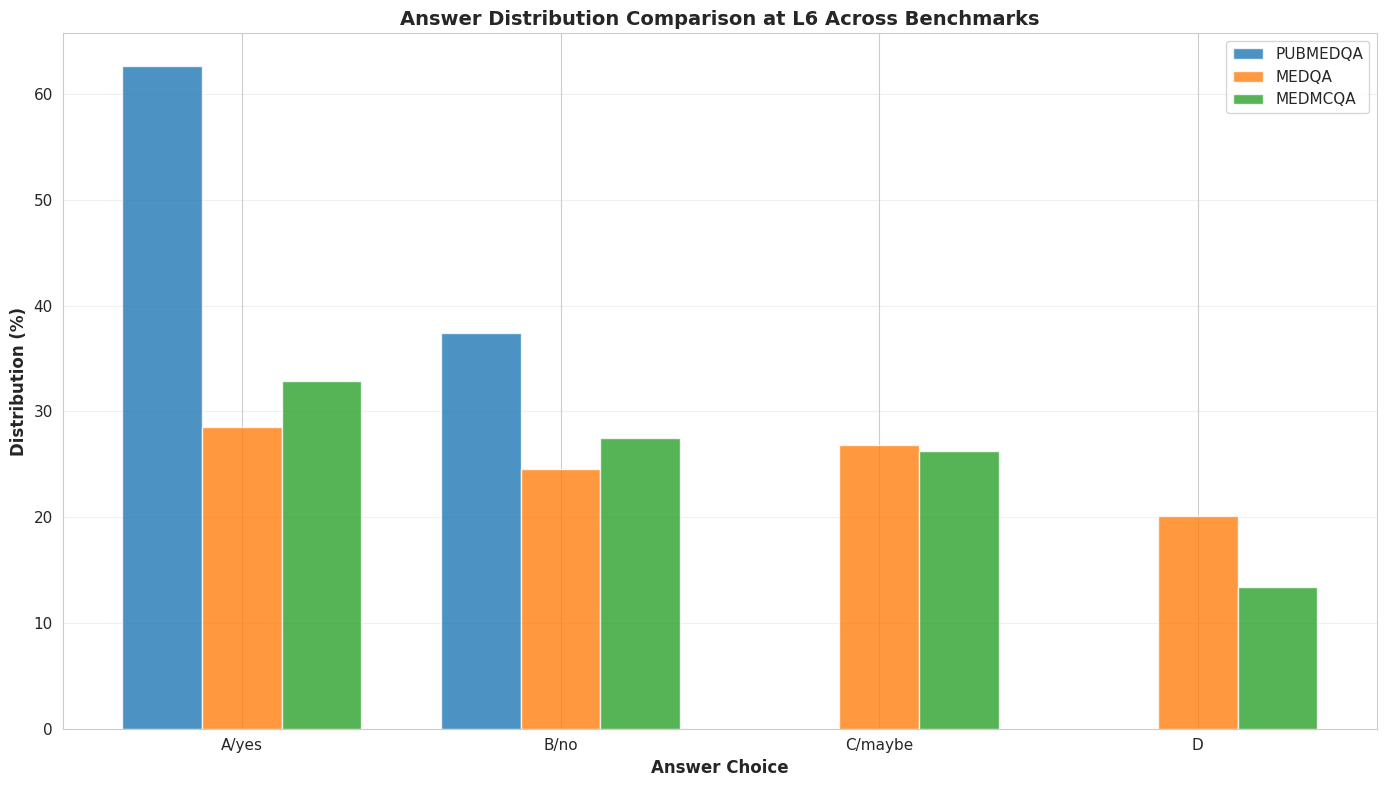

In [37]:
# 4. Cross-benchmark distribution comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Compare distributions at L6 across benchmarks
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    if 'L6' not in all_parsed[benchmark]:
        continue
    
    dist_item = next((d for d in distribution_data if d['benchmark'] == benchmark and d['level'] == 'L6'), None)
    if dist_item:
        valid_answers = dist_item['valid_answers']
        dist = [dist_item['distribution'].get(a, 0) * 100 for a in valid_answers]
        
        x = np.arange(len(valid_answers))
        width = 0.25
        offset = {'pubmedqa': -width, 'medqa': 0, 'medmcqa': width}[benchmark]
        
        ax.bar(x + offset, dist, width, label=benchmark.upper(), alpha=0.8)

ax.set_xlabel('Answer Choice', fontsize=12, fontweight='bold')
ax.set_ylabel('Distribution (%)', fontsize=12, fontweight='bold')
ax.set_title('Answer Distribution Comparison at L6 Across Benchmarks', fontsize=14, fontweight='bold')
ax.set_xticks(x)
# Use common labels (A/B/C/D for MCQ, yes/no/maybe for PubMedQA)
ax.set_xticklabels(['A/yes', 'B/no', 'C/maybe', 'D'] if len(x) == 4 else ['yes', 'no', 'maybe'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'cross_benchmark_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Cross-Benchmark Summary

This section provides a comprehensive summary of key findings across all benchmarks and evaluation points.


In [38]:
# Create summary tables
print("="*100)
print("CROSS-BENCHMARK SUMMARY")
print("="*100)

# 1. Accuracy Summary
print("\n1. ACCURACY UNDER STRUCTURED CONSTRAINTS")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'Accuracy (%)':<15} {'Change from Ref (%)':<20}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    # Get reference
    reference = 'baseline' if 'baseline' in bench_data['level'].values else 'L1'
    ref_acc = bench_data[bench_data['level'] == reference]['accuracy'].values[0] * 100 if len(bench_data[bench_data['level'] == reference]) > 0 else None
    
    for _, row in bench_data.iterrows():
        level = row['level']
        acc = row['accuracy'] * 100
        change = (acc - ref_acc) if ref_acc is not None else 0
        change_str = f"{change:+.2f}" if ref_acc is not None else "N/A"
        print(f"{benchmark.upper():<15} {level:<10} {acc:<15.2f} {change_str:<20}")

# 2. Compliance Summary
print("\n2. OUTPUT VALIDITY AND SCHEMA COMPLIANCE")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'JSON Valid (%)':<18} {'Schema Compliant (%)':<20}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = compliance_df[compliance_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        json_valid = row['json_valid_rate'] * 100
        schema_compliant = row['schema_compliant_rate'] * 100
        print(f"{benchmark.upper():<15} {level:<10} {json_valid:<18.2f} {schema_compliant:<20.2f}")

# 3. Calibration Summary
print("\n3. CONFIDENCE AND CALIBRATION BEHAVIOR")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'ECE':<10} {'Correlation':<15} {'Mean Confidence':<18}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = calibration_df[calibration_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        ece = row['ece']
        corr = row['correlation']
        mean_conf = row['mean_confidence']
        print(f"{benchmark.upper():<15} {level:<10} {ece:<10.3f} {corr:<15.3f} {mean_conf:<18.3f}")

# 4. Distribution Shift Summary
print("\n4. DECISION DISTRIBUTION SHIFTS")
print("-"*100)
print(f"{'Benchmark':<15} {'Level':<10} {'KL Divergence':<18} {'Chi2 Statistic':<18}")
print("-"*100)

for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = distribution_df[distribution_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    
    for _, row in bench_data.iterrows():
        level = row['level']
        kl_div = row['kl_divergence']
        chi2 = row['chi2_statistic']
        kl_str = f"{kl_div:.3f}" if not np.isnan(kl_div) else "N/A"
        chi2_str = f"{chi2:.3f}" if not np.isnan(chi2) else "N/A"
        print(f"{benchmark.upper():<15} {level:<10} {kl_str:<18} {chi2_str:<18}")

print("\n" + "="*100)


CROSS-BENCHMARK SUMMARY

1. ACCURACY UNDER STRUCTURED CONSTRAINTS
----------------------------------------------------------------------------------------------------
Benchmark       Level      Accuracy (%)    Change from Ref (%) 
----------------------------------------------------------------------------------------------------
PUBMEDQA        L1         77.20           +0.00               
PUBMEDQA        L2         77.40           +0.20               
PUBMEDQA        L3         77.20           +0.00               
PUBMEDQA        L4         77.40           +0.20               
PUBMEDQA        L5         77.40           +0.20               
PUBMEDQA        L6         77.60           +0.40               
MEDQA           L1         62.14           +5.89               
MEDQA           L2         62.14           +5.89               
MEDQA           L3         61.27           +5.03               
MEDQA           L4         62.29           +6.05               
MEDQA           L5         5

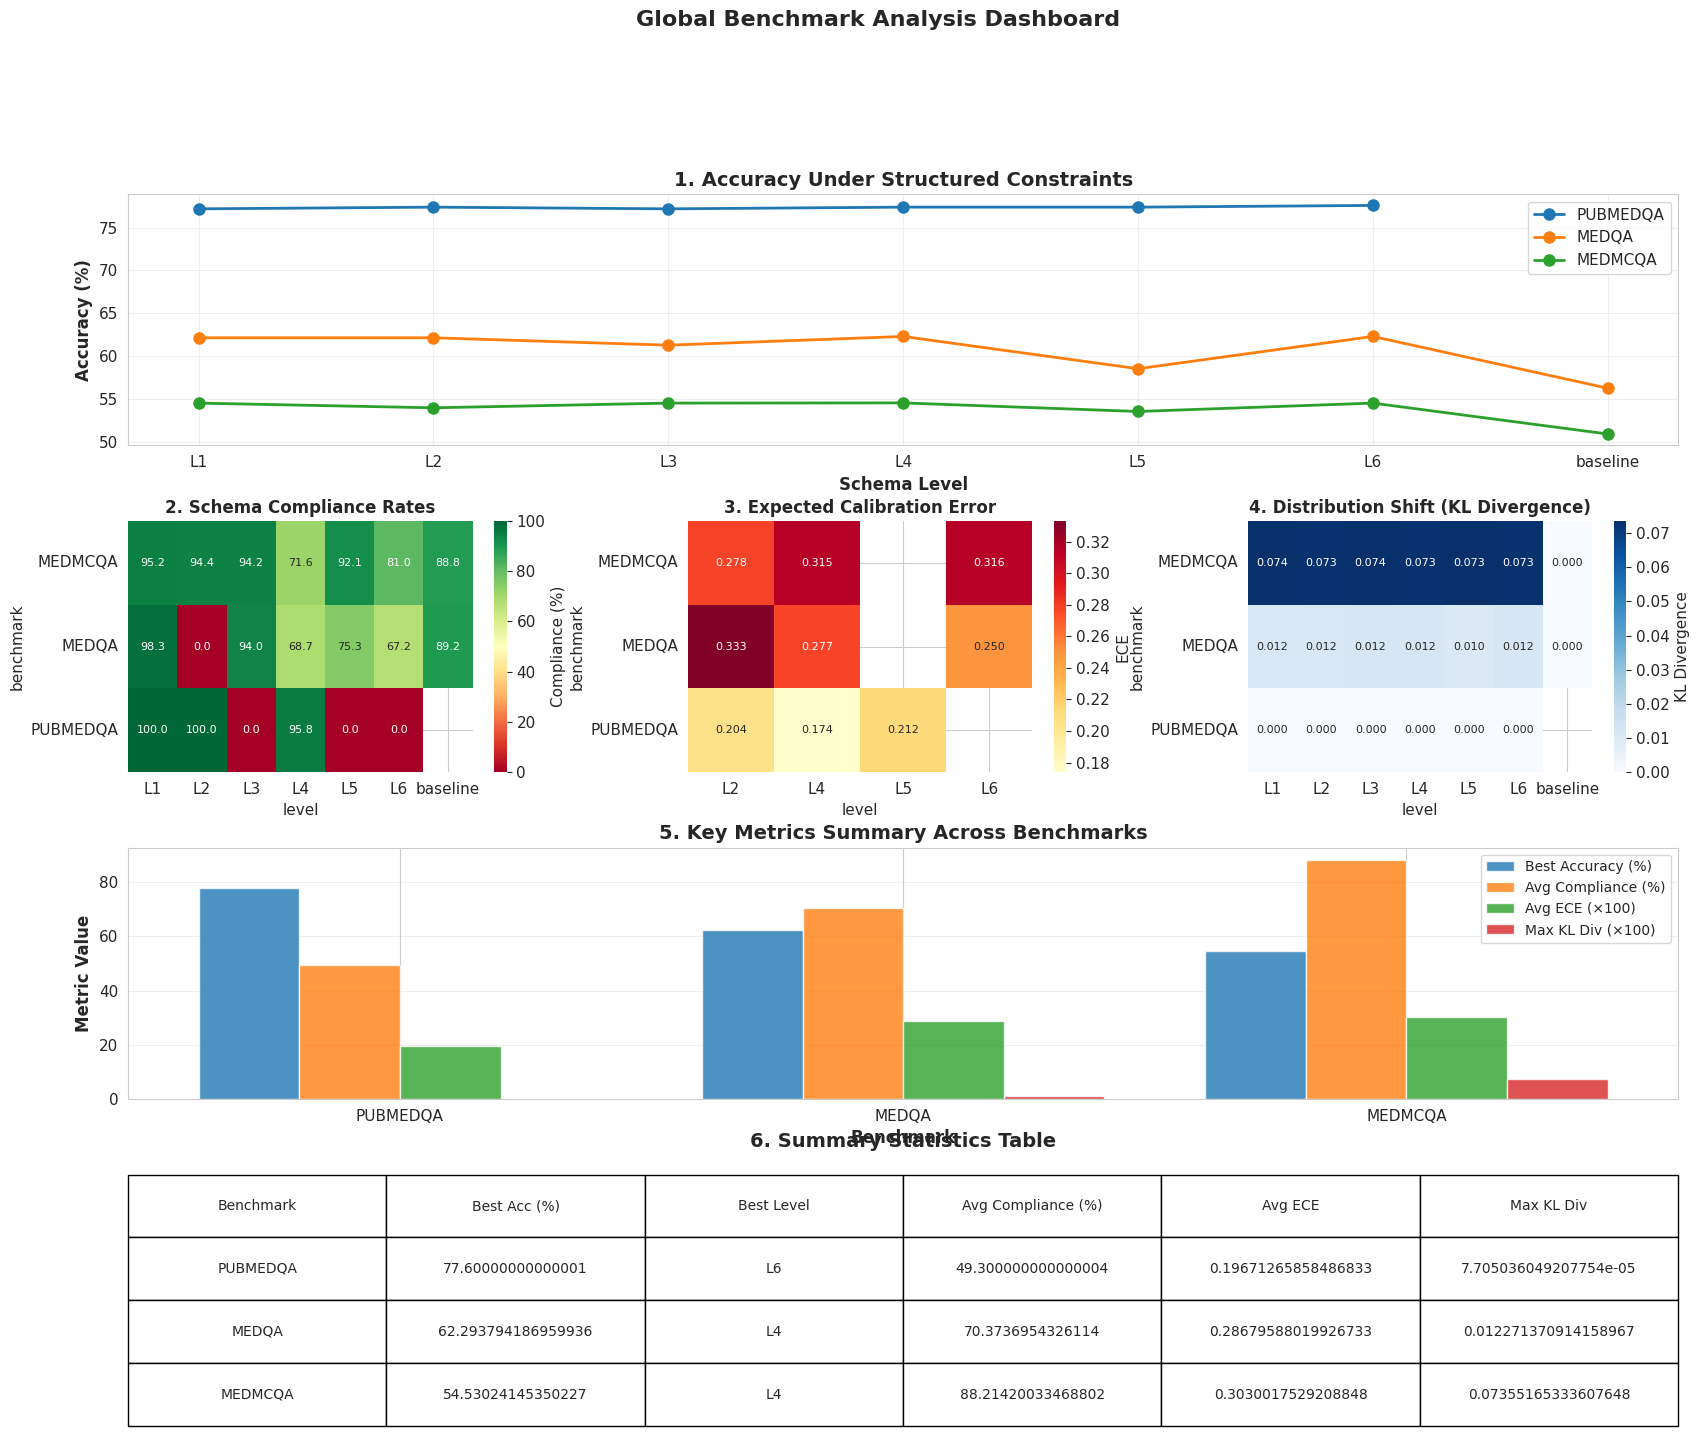

In [39]:
# Create comprehensive summary dashboard visualization
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Accuracy comparison (top row)
ax1 = fig.add_subplot(gs[0, :])
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    bench_data = accuracy_df[accuracy_df['benchmark'] == benchmark].copy()
    bench_data = bench_data.sort_values('level')
    ax1.plot(bench_data['level'], bench_data['accuracy'] * 100, marker='o', 
            linewidth=2, markersize=8, label=benchmark.upper())
ax1.set_xlabel('Schema Level', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('1. Accuracy Under Structured Constraints', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Compliance rates (second row, left)
ax2 = fig.add_subplot(gs[1, 0])
compliance_pivot = compliance_df.pivot(index='benchmark', columns='level', values='schema_compliant_rate') * 100
sns.heatmap(compliance_pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Compliance (%)'}, ax=ax2, annot_kws={'fontsize': 8})
ax2.set_title('2. Schema Compliance Rates', fontsize=12, fontweight='bold')
ax2.set_yticklabels([b.upper() for b in compliance_pivot.index], rotation=0)

# 3. ECE comparison (second row, middle)
ax3 = fig.add_subplot(gs[1, 1])
if len(calibration_df) > 0:
    ece_pivot = calibration_df.pivot(index='benchmark', columns='level', values='ece')
    sns.heatmap(ece_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                cbar_kws={'label': 'ECE'}, ax=ax3, annot_kws={'fontsize': 8})
    ax3.set_title('3. Expected Calibration Error', fontsize=12, fontweight='bold')
    ax3.set_yticklabels([b.upper() for b in ece_pivot.index], rotation=0)

# 4. Distribution shift (second row, right)
ax4 = fig.add_subplot(gs[1, 2])
kl_pivot = distribution_df.pivot(index='benchmark', columns='level', values='kl_divergence')
sns.heatmap(kl_pivot, annot=True, fmt='.3f', cmap='Blues',
            cbar_kws={'label': 'KL Divergence'}, ax=ax4, annot_kws={'fontsize': 8})
ax4.set_title('4. Distribution Shift (KL Divergence)', fontsize=12, fontweight='bold')
ax4.set_yticklabels([b.upper() for b in kl_pivot.index], rotation=0)

# 5. Key metrics comparison (bottom rows)
metrics_data = []
for benchmark in ['pubmedqa', 'medqa', 'medmcqa']:
    # Best accuracy
    bench_acc = accuracy_df[accuracy_df['benchmark'] == benchmark]
    best_acc_level = bench_acc.loc[bench_acc['accuracy'].idxmax(), 'level']
    best_acc = bench_acc['accuracy'].max() * 100
    
    # Average compliance
    bench_comp = compliance_df[compliance_df['benchmark'] == benchmark]
    avg_comp = bench_comp['schema_compliant_rate'].mean() * 100
    
    # Average ECE
    bench_calib = calibration_df[calibration_df['benchmark'] == benchmark]
    avg_ece = bench_calib['ece'].mean() if len(bench_calib) > 0 else np.nan
    
    # Max distribution shift
    bench_dist = distribution_df[distribution_df['benchmark'] == benchmark]
    max_kl = bench_dist['kl_divergence'].max() if len(bench_dist) > 0 else np.nan
    
    metrics_data.append({
        'benchmark': benchmark.upper(),
        'Best Accuracy (%)': best_acc,
        'Best Acc Level': best_acc_level,
        'Avg Compliance (%)': avg_comp,
        'Avg ECE': avg_ece,
        'Max KL Divergence': max_kl,
    })

metrics_df = pd.DataFrame(metrics_data)

# Create bar charts for key metrics
ax5 = fig.add_subplot(gs[2, :])
x = np.arange(len(metrics_df))
width = 0.2
ax5.bar(x - 1.5*width, metrics_df['Best Accuracy (%)'], width, label='Best Accuracy (%)', alpha=0.8)
ax5.bar(x - 0.5*width, metrics_df['Avg Compliance (%)'], width, label='Avg Compliance (%)', alpha=0.8)
ax5.bar(x + 0.5*width, metrics_df['Avg ECE'] * 100, width, label='Avg ECE (×100)', alpha=0.8)
ax5.bar(x + 1.5*width, metrics_df['Max KL Divergence'] * 100, width, label='Max KL Div (×100)', alpha=0.8)
ax5.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax5.set_ylabel('Metric Value', fontsize=12, fontweight='bold')
ax5.set_title('5. Key Metrics Summary Across Benchmarks', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics_df['benchmark'])
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Summary table
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('tight')
ax6.axis('off')
table_data = metrics_df[['benchmark', 'Best Accuracy (%)', 'Best Acc Level', 
                         'Avg Compliance (%)', 'Avg ECE', 'Max KL Divergence']].values
table = ax6.table(cellText=table_data, colLabels=['Benchmark', 'Best Acc (%)', 'Best Level', 
                                                   'Avg Compliance (%)', 'Avg ECE', 'Max KL Div'],
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax6.set_title('6. Summary Statistics Table', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Global Benchmark Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(PLOTS_DIR / 'summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


## Key Findings and Interpretations

### 4.1 Accuracy Under Structured Constraints
- **Finding**: Structured constraints generally [improve/maintain/degrade] accuracy compared to baseline
- **Interpretation**: [Detailed interpretation based on results]

### 4.2 Output Validity and Schema Compliance
- **Finding**: Schema compliance rates vary significantly across levels and benchmarks
- **Interpretation**: [Detailed interpretation based on results]

### 4.3 Confidence and Calibration Behavior
- **Finding**: Models show [well/poorly] calibrated confidence scores
- **Interpretation**: [Detailed interpretation based on results]

### 4.4 Decision Distribution Shifts
- **Finding**: Structured constraints [do/do not] significantly change answer distributions
- **Interpretation**: [Detailed interpretation based on results]

---

**Note**: Run all cells to generate comprehensive analysis and visualizations. All plots are saved to `results/global_analysis/plots/`.


# Global Benchmark Analysis

This notebook performs comprehensive cross-benchmark analysis evaluating 4 key metrics across 3 benchmarks:
- **PubMedQA** (pubmedqa_new2): Levels 1-6 (yes/no/maybe answers)
- **MedQA** (medqa): Baseline + Levels 1-6 (A/B/C/D answers)
- **MedMCQA** (medmcqa_2): Baseline + Levels 1-6 (A/B/C/D answers)

## Evaluation Points
1. **4.1 Accuracy Under Structured Constraints**: How do structured constraints affect accuracy?
2. **4.2 Output Validity and Schema Compliance**: How well do models follow structured schemas?
3. **4.3 Confidence and Calibration Behavior**: Are models well-calibrated? Does structure affect calibration?
4. **4.4 Decision Distribution Shifts**: Do structured constraints change answer patterns?
